In [5]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine

Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  Created wheel for fwiVis: filename=fwiVis-0.1-py3-none-any.whl size=17875 sha256=97ba9344485288491de7a70013b98c2a1b524924fbfc843f2d292de66653f5ab
  Stored in directory: /tmp/pip-ephem-wheel-cache-14ijjcbh/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [6]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date
from bs4 import BeautifulSoup
import requests
import os
import plotnine

In [152]:

import fwiVis.fwiVis as fv

#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_only/April_1_unmerged_fires_with_FWI.csv"
#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Final_dataset_as_of_20240209.csv"
#fire3 = fv.prep_fire_files(path)

path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
fire3 = fv.prep_fire_files(path)

#ciffc = pd.read_csv("/projects/old_shared/fire_weather_vis/Lightning_analysis/CIFFC_data/ciffc_all_canada.csv")
ciffc = pd.read_csv(os.path.abspath("contextual_data/CIFFC_data/ciffc_all_canada.csv"))
#ciffc = ciffc[ciffc.field_agency_code == "qc"]

ciffc = gpd.GeoDataFrame(ciffc, geometry= gpd.points_from_xy(ciffc.field_longitude, ciffc.field_latitude), crs = "4326")
ciffc = ciffc.to_crs("3571")

In [153]:
fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.FWI.isna()]
#fire3.farea = fire3.farea.astype("int64")
fire3 = fire3.sjoin(ciffc)
fire3["farea_diff"] = fire3.groupby("fireID").farea.diff()

row_mask = (~fire3.fireID.str.contains("_"))

#fire3[row_mask].hvplot.scatter(x='FWI', y='farea_diff', hover_cols=['fireID', 't'])
#fire3[row_mask].plot.scatter(x='FWI', y='farea_diff')

In [154]:
supression = fire3.groupby("fireID").field_response_type.unique().reset_index()
supression

supression["len"] = supression.field_response_type.apply(len)

multi_suppress_ids = supression[supression.len> 1].fireID

supression[supression.len> 1]
fire_ids_not_unique_supression = supression[supression.len> 1].fireID

In [10]:
print(fire3.fireID)

5616    1003
5618    1003
5620    1003
5622    1003
5624    1003
        ... 
5558     973
5560     973
5562     973
5564     973
5566     973
Name: fireID, Length: 9183, dtype: object


In [160]:
### Function that takes a point and looks for the multi polygons that intersect with that point. 
#It then assignes just the polygon portion of the multipolygon with the point's ID. 
# At the end, I want to put in an ID where there are two supression stratagies, and I want to get two IDs out, one per supression stratagy: subset to just the portion where there is one supression strategy.  
# I have found one fire so far (1082) where this wont work, because at least some probable fire that could/should be tied to one surpession strategy doesn't overlap with the point, even after the reported time, and by the time out polygon overlapped with the point it was already merged with anouther one. So boo. 

import shapely
import shapely.geometry as gmt
from shapely.geometry import MultiPolygon, Point, Polygon

def split_multipolygon(multipolygon, point):
    """Splits a MultiPolygon into separate polygons based on intersection with a point.

    Args:
        multipolygon (MultiPolygon): The MultiPolygon to split.
        point (Point): The point used to determine intersection.

    Returns:
        list: A list of individual polygons.
    """

    polygons = []
    for polygon in multipolygon:
        if polygon.intersects(point):
            polygons.append(polygon)
    return polygons


def exactly_one_true(lst):
    """Checks if exactly one element in the list is True."""
    return sum(lst) == 1

def sep_supression(fid, df1, meter_crs = 3571, point_crs = 4326):
    print("Assuming df1 is in  crs 4326")
    df = df1[df1.fireID == fid]
    #df = df[30:40]
    # df = df.to_crs(meter_crs)
    # df.geometry = df.geometry.buffer(500) ## 200 meeters
    # df = df.to_crs(point_crs)
    ciffc_resp = df.field_response_type.unique()
    resp_l = []
    #for r in ciffc_resp:
    just_intersect = []
    unique_points = df[["field_latitude", "field_longitude", "field_response_type", "field_agency_fire_id"]].drop_duplicates().reset_index(drop = True) # (df.field_response_type == r)
    unique_points = gpd.GeoDataFrame(unique_points, geometry= gpd.points_from_xy(unique_points.field_longitude, unique_points.field_latitude,  crs = 4326))
    #return(unique_points)
    points = [Point(lon, lat) for lon, lat in zip(unique_points.field_longitude, unique_points.field_latitude)]
    #print(len(points))
    #return(points)
    
    for index, row in df.iterrows(): # [df.field_response_type == r]
    #if isinstance(row['geometry'], MultiPolygon):
        #print("This is a multipolygon")
       #split_polygons = split_multipolygon(row['geometry'], intersection_point)
        ## Double check that only 1 point intersects with polygon. 
        if(isinstance(row['geometry'], Polygon)):
            row['geometry'] = gmt.MultiPolygon([row['geometry']])
        for polygon in row['geometry'].geoms:
            #print(shapely.intersects(points, polygon))
            unique_points["Does_it_intersect"] = np.nan
            intersecting_points = []
            for point in points:
                intersecting_points.append(polygon.intersects(point))
                    
            unique_points["Does_it_intersect"] = intersecting_points
            up_group = unique_points.groupby("field_response_type").Does_it_intersect.unique().reset_index()
            #return(up_group)

            only_one_type_of_supression_intersects = (sum(up_group.Does_it_intersect.explode().values) == 1)
            #intersecting_points = [point for point in points if polygon.intersects(point)]
            #print(intersecting_points)

            #if len(intersecting_points) == 1:  # Exactly one point intersects
            if only_one_type_of_supression_intersects: ### Only one catagory intersects with this polygon
                #print(only_one_type_of_supression_intersects)
                #return(up_group)
                new_row = row.copy()
                new_row["geometry"] = polygon
                
                # try:
                    #new_row["fireID"] = str(fid) + "." +str(up_group[up_group.Does_it_intersect.sum()].field_response_type.iloc[0])# tmp2[tmp2.source.explode()].degree.iloc[0]
                    #new_row["fireID"] = str(fid) + "." +str(up_group[up_group.Does_it_intersect.apply(any)].field_response_type.iloc[0]) + "." + str(*unique_points[unique_points.Does_it_intersect == True].field_agency_fire_id.unique())
                new_row["fireID"] = str(fid) + "." +str(up_group[up_group.Does_it_intersect.apply(any)].field_response_type.iloc[0]) +"." +  ".".join(unique_points[unique_points.Does_it_intersect == True].field_agency_fire_id.astype("str"))
                    
                # except:
                #     return(unique_points)
                # #     return(up_group)
                    
                just_intersect.append(new_row)
                # fig, ax = plt.subplots(figsize=(8, 6))
                # #print(type(new_row))
                # #new_row.plot(color = "green")
                # plt.plot(*new_row["geometry"].exterior.xy, color = "green")
                # for point in points:
                #     ax.plot(point.x, point.y, 'ro', label="Point")  # 'ro' for red points
                
                #     # Adjust the plot
                #     ax.set_title("Geometry and Points")
                #     ax.set_xlabel("Longitude")
                #     ax.set_ylabel("Latitude")
                #     plt.grid(True)
                    
                #     # Show the plot
                #     plt.show()
                #plt.plot(*new_row["geometry"].exterior.xy, color = "green")
                #plt.plot(*unique_points["geometry"].exterior.xy, color = "red")
                #unique_points.plot(color = "red")
                #plt.plot(unique_points.field_longitude, unique_points.field_latitude,  color = "red")
                #plt.show()
            else:
                new_row = row.copy()
                new_row["geometry"] = polygon
                # fig, ax = plt.subplots(figsize=(8, 6))
                # plt.plot(*new_row["geometry"].exterior.xy, color = "yellow")
                # for point in points:
                #     ax.plot(point.x, point.y, 'ro', label="Point")  # 'ro' for red points
                
                #     # Adjust the plot
                #     ax.set_title("Geometry and Points")
                #     ax.set_xlabel("Longitude")
                #     ax.set_ylabel("Latitude")
                #     plt.grid(True)
                    
                #     # Show the plot
                #     plt.show()
                #plt.plot(*new_row["geometry"].exterior.xy, color = "yellow")
                #plt.plot(unique_points.field_longitude, unique_points.field_latitude,  color = "red")
                #plt.plot(*unique_points["geometry"].exterior.xy, color = "red")
                #unique_points.plot(color = "red")
                #plt.show()
                #print("skipping")
                #just_intersect.append(None)
    # else:
    #     just_intersect.append(row)
    just_intersect_df = gpd.GeoDataFrame(just_intersect)
    # if(len(just_intersect_df) > 0):
    #     #print(just_intersect)
    #     just_intersect_df.fireID = just_intersect_df.fireID.astype("str") + "." + r
    #     #print(just_intersect_df)
    #     resp_l.append(just_intersect_df)
    # else:
    #     print(f"{fid} had no independant multi-polygons to split")
#full_df = pd.concat(resp_l, axis=0)
    return(just_intersect_df)
    

def check_that_continious_record(df):
    min_t = df.t.min()
    max_t = df.t.max()
    #dates = pd.date_range(start= min_t, end=  max_t).to_pydatetime().tolist()
    dates = pd.date_range(start= min_t, end=  max_t).strftime('%Y-%m-%d 12:00:00').tolist()
    len_df = len(df.t.unique())
    #print(df.t.unique())
    len_seq = len(dates)
    #print(dates)
    if(len_df != len_seq):
        print(f"FireID {df.fireID.unique()} is not a continious sequence.")
        return(False)
    d_list = []
    for d in dates:
        some_dates = df[df.t == d]
        d_list.append(len(some_dates) > 0)
    return(any(d_list))
        

    

In [138]:
# check_that_continious_record(foo[foo.fireID == "226.MON.219"])

In [133]:
# temp = pd.date_range(start= '2023-06-01 12:00:00', end=  '2023-06-03 12:00:00').strftime('%Y-%m-%d 12:00:00').tolist()

# temp

In [ ]:
#foo = sep_supression("2545", fire3.to_crs(4326))

In [140]:
### Check that each is continious

,fireID,t,geometry,Unnamed: 0,mergeid,ftype,n_pixels,n_newpixels,farea,fperim,...,field_situation_report_date,field_status_date,field_stage_of_control_status,field_system_fire_cause,field_response_type,field_fire_size,field_latitude,field_longitude,full_count,farea_diff
10065,2545.MOD575,2023-07-05 12:00:00,"POLYGON ((-77.34546 51.31321, -77.34551 51.313...",10065,2545,0,30,30,7.848757,13.797199,...,2023-07-05T15:39:00.000Z,2023-11-23T20:02:34.000Z,OUT,N,MOD,52014.1,51.3069,-77.3306,6668,NaN
10067,2545.MOD575,2023-07-06 12:00:00,"POLYGON ((-77.34546 51.31321, -77.34551 51.313...",10067,2545,0,30,0,7.848757,13.797199,...,2023-07-05T15:39:00.000Z,2023-11-23T20:02:34.000Z,OUT,N,MOD,52014.1,51.3069,-77.3306,6668,0.000000
10069,2545.MOD575,2023-07-07 12:00:00,"POLYGON ((-77.31132 51.32584, -77.30359 51.326...",10069,2545,0,83,51,17.889407,27.504183,...,2023-07-05T15:39:00.000Z,2023-11-23T20:02:34.000Z,OUT,N,MOD,52014.1,51.3069,-77.3306,6668,10.040650
10071,2545.MOD575,2023-07-08 12:00:00,"POLYGON ((-77.21138 51.36533, -77.21115 51.365...",10071,2545,0,280,0,32.055190,41.550671,...,2023-07-05T15:39:00.000Z,2023-11-23T20:02:34.000Z,OUT,N,MOD,52014.1,51.3069,-77.3306,6668,14.165783
10073,2545.MOD575,2023-07-09 12:00:00,"POLYGON ((-77.19693 51.34368, -77.19428 51.341...",10073,2545,0,308,20,37.703964,40.717118,...,2023-07-05T15:39:00.000Z,2023-11-23T20:02:34.000Z,OUT,N,MOD,52014.1,51.3069,-77.3306,6668,5.648773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10157,2545.MOD575.577,2023-08-20 12:00:00,"POLYGON ((-77.18504 51.50759, -77.17271 51.509...",10157,2545,0,7466,0,697.695274,166.006416,...,2023-07-05T16:29:00.000Z,2023-11-22T15:19:40.000Z,OUT,N,MOD,6964.4,51.2200,-77.1336,6668,0.000000
10159,2545.MOD575.577,2023-08-21 12:00:00,"POLYGON ((-77.18504 51.50759, -77.17271 51.509...",10159,2545,0,7466,0,697.695274,166.006416,...,2023-07-05T15:39:00.000Z,2023-11-23T20:02:34.000Z,OUT,N,MOD,52014.1,51.3069,-77.3306,6668,0.000000
10159,2545.MOD575.577,2023-08-21 12:00:00,"POLYGON ((-77.18504 51.50759, -77.17271 51.509...",10159,2545,0,7466,0,697.695274,166.006416,...,2023-07-05T16:29:00.000Z,2023-11-22T15:19:40.000Z,OUT,N,MOD,6964.4,51.2200,-77.1336,6668,0.000000
10161,2545.MOD575.577,2023-08-22 12:00:00,"POLYGON ((-77.21476 51.52746, -77.21454 51.527...",10161,2545,0,7467,1,697.695276,166.006443,...,2023-07-05T15:39:00.000Z,2023-11-23T20:02:34.000Z,OUT,N,MOD,52014.1,51.3069,-77.3306,6668,0.000002


In [143]:
#".".join(unique_points[unique_points.Does_it_intersect == True].field_agency_fire_id.astype("str"))

In [86]:
# #tmp_foo = foo
# #foo["test_col"] = [[True], [True, False]]

# #foo[foo.Does_it_intersect == True]
# #foo[foo.test_col == True]
# foo[foo.Does_it_intersect.apply(any)].field_response_type.iloc[0]

#tmp = fire3.iloc[0]

# foo.fireID.unique()

In [87]:
# fire3[fire3.fireID == "226"].field_agency_fire_id.unique()

In [88]:
# isinstance(tmp["geometry"], Polygon)

In [89]:
# gmt.MultiPolygon([tmp["geometry"]])

In [90]:
# #foo[foo.Does_it_intersect.sum()].field_response_type.iloc[0]

# #foo[sum(foo.Does_it_intersect.explode().values) == 1]


# #sum(foo.Does_it_intersect.explode().values) == 1

# #foo

# #foo.Does_it_intersect.sum()

# foo

In [91]:
# ### I want this to return "True"
# deg = ["MBA", "MBA", "M.Tech"]
# scr = [True, True, False]
 
# # dictionary of lists 
# dict = {'source': scr, 'degree': deg}
# tmp = pd.DataFrame(dict)

# print(*tmp.groupby("degree").source.unique().reset_index().source.values)
# len(tmp.groupby("degree").source.unique().reset_index().source)
# #len([*tmp.groupby("degree").source.unique()])
# sum(tmp.groupby("degree").source.unique().reset_index().source.explode().values)

# tmp2 = tmp.groupby("degree").source.unique().reset_index()
# print(tmp2)
# tmp2[tmp2.source.explode()].degree.iloc[0]

In [92]:
# ### I want this to return "True"
# deg = ["MBA", "JD", "M.Tech"]
# scr = [True, False, False]
 
# # dictionary of lists 
# dict = {'name': nme, 'degree': deg}
# pd.DataFrame(dict)

In [93]:
# ### I want this to return "False"
# deg = ["MBA", "JD", "M.Tech"]
# scr = [True, True, False]
 
# # dictionary of lists 
# dict = {'name': nme, 'degree': deg}
# pd.DataFrame(dict)

In [94]:
# ### I want this to return "False"
# deg = ["MBA", "JD", "M.Tech"]
# scr = [True, True, True]
 
# # dictionary of lists 
# dict = {'name': nme, 'degree': deg}
# pd.DataFrame(dict)

In [95]:
# ### I want this to return "False"
# deg = ["MBA", "JD",  "JD", "M.Tech"]
# scr = [True, False,  True, False]
 
# # dictionary of lists 
# dict = {'name': nme, 'degree': deg}
# pd.DataFrame(dict)

In [96]:
# #len(fire3.geometry.iloc[27].geoms)

# foo = sep_supression("226", fire3.to_crs(4326))
# #print(len(foo[0]))
# # print(len(fire3[fire3.fireID == "1088"]))
# # foo.fireID.unique()
# # type(foo)
# # foo.columns
# #print(*foo)
# print(foo)

# # plt.plot(foo.field_longitude, foo.field_latitude,  color = "red")
# # plt.show()

# #foo.plot(col)

In [97]:
# #foo[foo.fireID == "226.MOD"].sort_values(by = "t").explore()
# foo.explore()

In [98]:
# isinstance(foo.geometry.iloc[1], MultiPolygon)

In [99]:
# #m = foo[0:4].explore()
# #m = foo[foo.fireID == "226.MOD" ].explore()
# m = foo.explore()
# tmp.explore(m = m, color = "red",  style_kwds = {"facecolor": None, "alpha": 0.7})


In [100]:

# #foo = foo[["field_latitude", "field_longitude"]].drop_duplicates().reset_index(drop = True)
# for f in foo.index:
#     print(f)

# foo.field_latitude.iloc[0]

In [101]:
# m = fire3.to_crs("4326")[(fire3.fireID == "1324") & (fire3.t == '2023-06-25 12:00:00')][['fireID', 't',
#        'field_agency_fire_id', 
#        'field_situation_report_date', 
#        'field_system_fire_cause', 'field_response_type', 'geometry'] ].explore(style_kwds = {"facecolor": None, "alpha": 0.7})

# tmp = fire3.to_crs(4326)[(fire3.fireID == "1324") & (fire3.t == '2023-06-22 12:00:00')][['fireID', 't',
#        'field_agency_fire_id', 'field_situation_report_date', 
#        'field_system_fire_cause', 'field_response_type', 'field_latitude', 'field_longitude'] ]#.explore(style_kwds = {"facecolor": None, "alpha": 0.7})
# tmp = gpd.GeoDataFrame(tmp, geometry = gpd.points_from_xy(tmp.field_longitude, tmp.field_latitude), crs = "4326")

# tmp.explore(m = m, color = "red",  style_kwds = {"facecolor": None, "alpha": 0.7})

In [102]:
# m = fire3.to_crs("4326")[(fire3.fireID == "226") & (fire3.t == '2023-06-17 12:00:00')][['fireID', 't',
#        'field_agency_fire_id', 
#        'field_situation_report_date', 
#        'field_system_fire_cause', 'field_response_type', 'geometry'] ].explore(style_kwds = {"facecolor": None, "alpha": 0.7})

# tmp = fire3.to_crs(4326)[(fire3.fireID == "226") ][['fireID', 't',
#        'field_agency_fire_id', 'field_situation_report_date', 
#        'field_system_fire_cause', 'field_response_type', 'field_latitude', 'field_longitude'] ]#.explore(style_kwds = {"facecolor": None, "alpha": 0.7})
# tmp = gpd.GeoDataFrame(tmp, geometry = gpd.points_from_xy(tmp.field_longitude, tmp.field_latitude), crs = "4326")

# tmp.explore(m = m, color = "red",  style_kwds = {"facecolor": None, "alpha": 0.7})

In [103]:
# m = fire3.to_crs("4326")[(fire3.fireID == "1082") & (fire3.t == '2023-06-22 12:00:00')][['fireID', 't',
#        'field_agency_fire_id', 
#        'field_situation_report_date', 
#        'field_system_fire_cause', 'field_response_type', 'geometry'] ].explore(style_kwds = {"facecolor": None, "alpha": 0.7})

# tmp = fire3.to_crs(4326)[(fire3.fireID == "1082") & (fire3.t == '2023-06-22 12:00:00')][['fireID', 't',
#        'field_agency_fire_id', 'field_situation_report_date', 
#        'field_system_fire_cause', 'field_response_type', 'field_latitude', 'field_longitude'] ]#.explore(style_kwds = {"facecolor": None, "alpha": 0.7})
# tmp = gpd.GeoDataFrame(tmp, geometry = gpd.points_from_xy(tmp.field_longitude, tmp.field_latitude), crs = "4326")

# tmp.explore(m = m, color = "red",  style_kwds = {"facecolor": None, "alpha": 0.7})

In [155]:
### remake IDs with duel supression status 


skip_list = ["1082", 
            "1324"] ### has more than one supression, but seems like the reported point doesn't overlap with an indepandant multipolygon. 

duel_sup =  [item for item in fire_ids_not_unique_supression if item not in skip_list]
dfs = []
for s in duel_sup:
    print(s)
    tmp = sep_supression(str(s), fire3.to_crs(4326))
    dfs.append(tmp)
foo = pd.concat(dfs)
foo

1088
Assuming df1 is in  crs 4326
226
Assuming df1 is in  crs 4326
2545
Assuming df1 is in  crs 4326
2647
Assuming df1 is in  crs 4326
2649
Assuming df1 is in  crs 4326
293
Assuming df1 is in  crs 4326
605
Assuming df1 is in  crs 4326


,fireID,t,geometry,Unnamed: 0,mergeid,ftype,n_pixels,n_newpixels,farea,fperim,...,field_situation_report_date,field_status_date,field_stage_of_control_status,field_system_fire_cause,field_response_type,field_fire_size,field_latitude,field_longitude,full_count,farea_diff
5874,1088.MOD.468,2023-06-11 12:00:00,"POLYGON ((-72.41448 53.94212, -72.41475 53.942...",5874,1088,0,32,32,4.709660,11.271193,...,2023-06-10T22:37:00.000Z,2023-11-22T16:37:30.000Z,OUT,N,MON,96803.4,54.0028,-72.1719,6668,NaN
5874,1088.MON.469,2023-06-11 12:00:00,"POLYGON ((-72.15447 54.00225, -72.15422 53.996...",5874,1088,0,32,32,4.709660,11.271193,...,2023-06-10T22:37:00.000Z,2023-11-22T16:37:30.000Z,OUT,N,MON,96803.4,54.0028,-72.1719,6668,NaN
5874,1088.MOD.468,2023-06-11 12:00:00,"POLYGON ((-72.41448 53.94212, -72.41475 53.942...",5874,1088,0,32,32,4.709660,11.271193,...,2023-06-10T22:40:00.000Z,2023-11-22T13:54:21.000Z,OUT,N,MOD,29660.8,53.9519,-72.4031,6668,0.000000
5874,1088.MON.469,2023-06-11 12:00:00,"POLYGON ((-72.15447 54.00225, -72.15422 53.996...",5874,1088,0,32,32,4.709660,11.271193,...,2023-06-10T22:40:00.000Z,2023-11-22T13:54:21.000Z,OUT,N,MOD,29660.8,53.9519,-72.4031,6668,0.000000
5876,1088.MOD.468,2023-06-12 12:00:00,"POLYGON ((-72.41231 53.95483, -72.41231 53.954...",5876,1088,0,203,112,20.684844,26.348460,...,2023-06-10T22:37:00.000Z,2023-11-22T16:37:30.000Z,OUT,N,MON,96803.4,54.0028,-72.1719,6668,15.975184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2415,293.MON.COC_FIRE_007,2023-06-21 12:00:00,"POLYGON ((-79.62829 49.01134, -79.626 49.00998...",2415,293,0,1639,177,225.608874,137.541272,...,2023-06-01T20:56:00.000Z,2023-11-15T18:43:49.000Z,OUT,N,FUL,10541.8,49.0622,-79.3578,6668,0.000000
2415,293.FUL.281.701.280.313,2023-06-21 12:00:00,"POLYGON ((-79.51024 49.07854, -79.51023 49.078...",2415,293,0,1639,177,225.608874,137.541272,...,2023-06-01T20:56:00.000Z,2023-11-15T18:43:49.000Z,OUT,N,FUL,10541.8,49.0622,-79.3578,6668,0.000000
4824,605.MON.SUD_FIRE_014,2023-06-07 12:00:00,"POLYGON ((-81.81592 46.55266, -81.81593 46.552...",4824,605,0,38,19,5.627833,12.561090,...,2023-06-02T23:04:00.000Z,2023-06-06T23:26:00.000Z,OUT,N,MON,63.0,46.5852,-81.8167,6668,NaN
4824,605.MON.SUD_FIRE_014,2023-06-07 12:00:00,"POLYGON ((-81.81592 46.55266, -81.81593 46.552...",4824,605,0,38,19,5.627833,12.561090,...,2023-06-02T23:03:00.000Z,2023-07-13T19:20:00.000Z,OUT,N,FUL,1291.9,46.5705,-81.8123,6668,0.000000


In [157]:
#sep_supression(str(1088), fire3.to_crs(4326))

In [159]:
#### Check that there is a continious t 


bools = foo.groupby("fireID").apply(check_that_continious_record)
print(f"Are all the fires continuios records???: {all(bools)}")

if(all(bools))
    fire3 = fire3[~fire3.fireID.isin(fire_ids_not_unique_supression)]
    fire3 = pd.concat([fire3, foo]ignore_index=True)

['2023-06-11 12:00:00' '2023-06-12 12:00:00' '2023-06-13 12:00:00'
 '2023-06-14 12:00:00' '2023-06-15 12:00:00' '2023-06-16 12:00:00'
 '2023-06-17 12:00:00' '2023-06-18 12:00:00' '2023-06-19 12:00:00'
 '2023-06-20 12:00:00' '2023-06-21 12:00:00']
['2023-06-11 12:00:00', '2023-06-12 12:00:00', '2023-06-13 12:00:00', '2023-06-14 12:00:00', '2023-06-15 12:00:00', '2023-06-16 12:00:00', '2023-06-17 12:00:00', '2023-06-18 12:00:00', '2023-06-19 12:00:00', '2023-06-20 12:00:00', '2023-06-21 12:00:00']
['2023-06-11 12:00:00' '2023-06-12 12:00:00' '2023-06-13 12:00:00'
 '2023-06-14 12:00:00' '2023-06-15 12:00:00' '2023-06-16 12:00:00'
 '2023-06-17 12:00:00' '2023-06-18 12:00:00' '2023-06-19 12:00:00'
 '2023-06-20 12:00:00' '2023-06-21 12:00:00']
['2023-06-11 12:00:00', '2023-06-12 12:00:00', '2023-06-13 12:00:00', '2023-06-14 12:00:00', '2023-06-15 12:00:00', '2023-06-16 12:00:00', '2023-06-17 12:00:00', '2023-06-18 12:00:00', '2023-06-19 12:00:00', '2023-06-20 12:00:00', '2023-06-21 12:00:00'

/tmp/ipykernel_4538/2991242641.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [ ]:
fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.FWI.isna()]
#fire3.farea = fire3.farea.astype("int64")
#fire3["farea_diff"] = fire3.groupby("fireID").farea.diff()

#row_mask = (~fire3.fireID.str.contains("_")) & (~fire3.fireID.isin(fire_ids_not_unique_supression))


#fire3[row_mask]
#fire3[row_mask].hvplot.scatter(x='FWI', y='farea_diff', hover_cols=['fireID', 't'])
#fire3[row_mask].plot.scatter(x='FWI', y='farea_diff')

,fireID,t,geometry,Unnamed: 0,mergeid,ftype,n_pixels,n_newpixels,farea,fperim,...,field_situation_report_date,field_status_date,field_stage_of_control_status,field_system_fire_cause,field_response_type,field_fire_size,field_latitude,field_longitude,full_count,farea_diff
5616,1003,2023-06-12 12:00:00,"POLYGON ((4110786.553 1263681.134, 4110785.796...",5616,1003,0,145,46,32.404016,27.030298,...,2023-06-05T23:03:00.000Z,2023-09-19T20:05:27.000Z,OUT,N,FUL,14225.5,50.6786,-72.8358,6668,NaN
5618,1003,2023-06-13 12:00:00,"POLYGON ((4108851.449 1257498.625, 4108850.964...",5618,1003,0,930,652,153.693232,55.798608,...,2023-06-05T23:03:00.000Z,2023-09-19T20:05:27.000Z,OUT,N,FUL,14225.5,50.6786,-72.8358,6668,121.289216
5620,1003,2023-06-14 12:00:00,"POLYGON ((4108851.449 1257498.625, 4108850.964...",5620,1003,0,930,0,153.693232,55.798608,...,2023-06-05T23:03:00.000Z,2023-09-19T20:05:27.000Z,OUT,N,FUL,14225.5,50.6786,-72.8358,6668,0.000000
5622,1003,2023-06-15 12:00:00,"POLYGON ((4108851.449 1257498.625, 4108850.964...",5622,1003,0,930,0,153.693232,55.798608,...,2023-06-05T23:03:00.000Z,2023-09-19T20:05:27.000Z,OUT,N,FUL,14225.5,50.6786,-72.8358,6668,0.000000
5624,1003,2023-06-16 12:00:00,"POLYGON ((4108851.449 1257498.625, 4108850.964...",5624,1003,0,930,0,153.693232,55.798608,...,2023-06-05T23:03:00.000Z,2023-09-19T20:05:27.000Z,OUT,N,FUL,14225.5,50.6786,-72.8358,6668,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5558,973,2023-06-25 12:00:00,"POLYGON ((4664345.741 654082.102, 4664342.543 ...",5558,973,0,52,0,6.335632,9.321320,...,2023-06-04T16:37:00.000Z,2023-07-12T22:00:00.000Z,OUT,N,FUL,459.0,46.7506,-81.9973,6668,0.000000
5560,973,2023-06-26 12:00:00,"POLYGON ((4664345.741 654082.102, 4664342.543 ...",5560,973,0,52,0,6.335632,9.321320,...,2023-06-04T16:37:00.000Z,2023-07-12T22:00:00.000Z,OUT,N,FUL,459.0,46.7506,-81.9973,6668,0.000000
5562,973,2023-06-27 12:00:00,"POLYGON ((4664345.741 654082.102, 4664342.543 ...",5562,973,0,52,0,6.335632,9.321320,...,2023-06-04T16:37:00.000Z,2023-07-12T22:00:00.000Z,OUT,N,FUL,459.0,46.7506,-81.9973,6668,0.000000
5564,973,2023-06-28 12:00:00,"POLYGON ((4664345.741 654082.102, 4664342.543 ...",5564,973,0,52,0,6.335632,9.321320,...,2023-06-04T16:37:00.000Z,2023-07-12T22:00:00.000Z,OUT,N,FUL,459.0,46.7506,-81.9973,6668,0.000000


In [30]:
# print(fire3.columns)

# f_467 = fire3[(fire3.fireID == "1082") & (fire3.field_agency_fire_id == "467")][['fireID', 't',
#        'field_agency_fire_id', 
#        'field_status_date', 
#        'field_system_fire_cause', 'field_response_type', 'geometry', 'field_latitude', 'field_longitude'] ].t

# f_537 = fire3[(fire3.fireID == "1082") & (fire3.field_agency_fire_id == "534")][['fireID', 't',
#        'field_agency_fire_id', 
#        'field_status_date', 
#        'field_system_fire_cause', 'field_response_type', 'geometry', 'field_latitude', 'field_longitude'] ].t

# fire3[(fire3.fireID == "1082") & (fire3.t.isin(f_467)) & (fire3.t.isin(f_537))][['fireID', 't',
#        'field_agency_fire_id', 
#        'field_status_date', 
#        'field_system_fire_cause', 'field_response_type', 'geometry', 'field_latitude', 'field_longitude'] ]#.explore(style_kwds = {"facecolor": None})

# # (fire3.field_agency_fire_id == "534")

In [31]:
# #smf.glm
# fire3.loc[row_mask, ['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
# 'field_response_type', 
# 'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling"]].field_response_type

In [14]:
fire3["FWI_diff"] = fire3.groupby("fireID").FWI.diff()
fire3["farea_diff"] = fire3.groupby("fireID").farea.diff()

row_mask = (~fire3.fireID.str.contains("_"))

#fire3[row_mask].hvplot.scatter(x='FWI_diff', y='farea_diff', hover_cols=['fireID', 't'])
#fire3[row_mask].plot.scatter(x='FWI', y='farea_diff')

In [15]:
fire3["FWI_rolling"] = fire3.groupby("fireID").FWI.rolling(3).max().reset_index(drop = True)

#fire3.groupby("fireID").FWI.rolling(3).mean()

In [16]:
row_mask = (~fire3.fireID.str.contains("_"))

#fire3[row_mask].hvplot.scatter(x='FWI_rolling', y='farea_diff', hover_cols=['fireID', 't'])

In [17]:
row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1)

#fire3[row_mask].hvplot.scatter(x='FWI_rolling', y='farea', hover_cols=['fireID', 't'])

In [11]:
# test = fire3.groupby("fireID").day_of_fire.max()
# test



### Get fireIDs that last longer than three days

def normalize_fwi(df, col = "FWI"):
    #print(df[col].mean())
    df[col+"_norm"] = df[col]/df[col].mean()
    return(df)

fire3 = fire3.groupby("fireID").apply(normalize_fwi).reset_index(drop = True)

/tmp/ipykernel_2194/184993424.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


/tmp/ipykernel_2194/3873461007.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/srv/conda/envs/notebook/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 179 rows containing missing values.


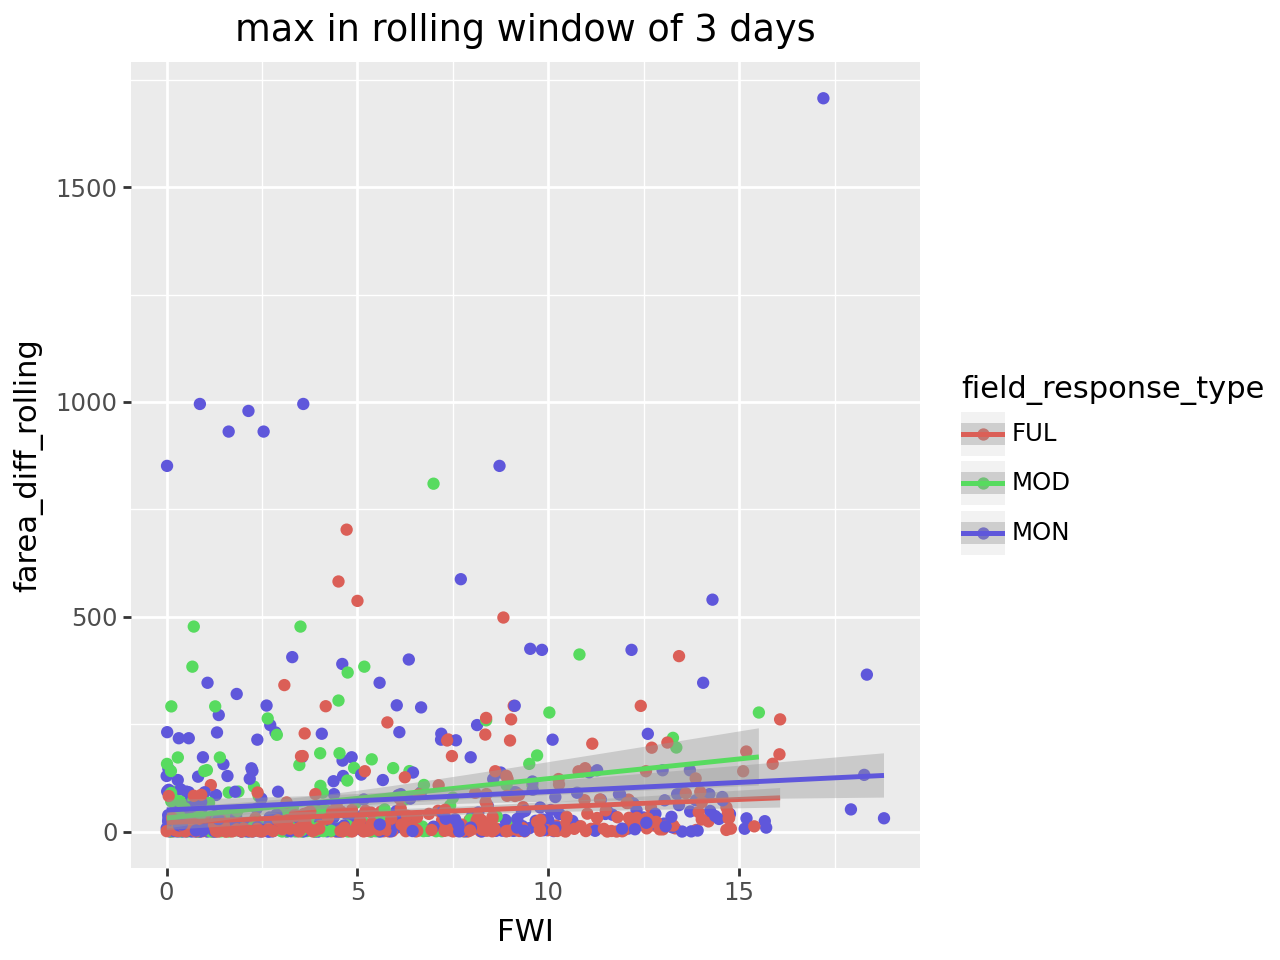

<ggplot: (640 x 480)>


/srv/conda/envs/notebook/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 179 rows containing missing values.


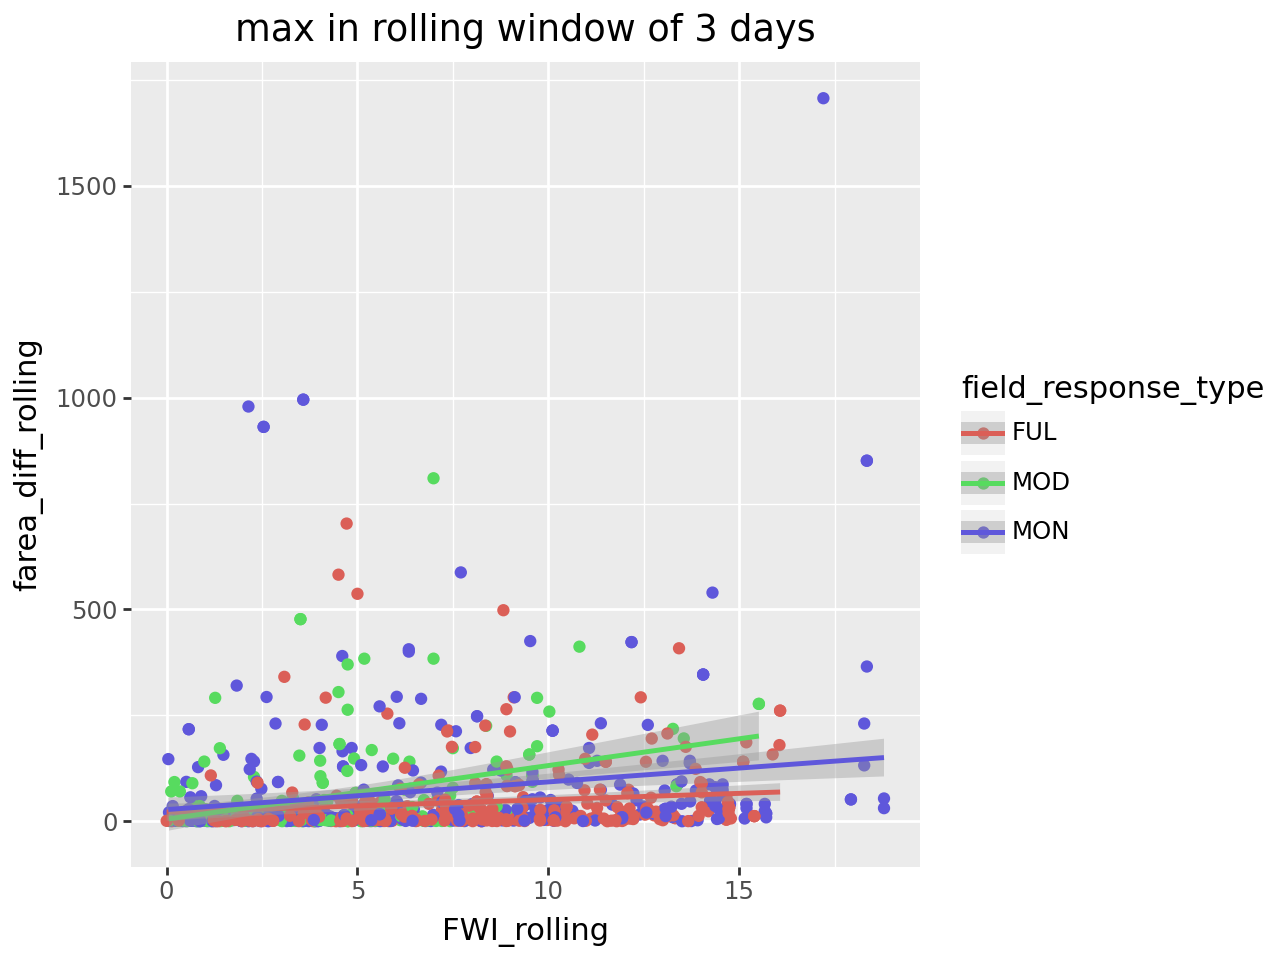

<ggplot: (640 x 480)>


/srv/conda/envs/notebook/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 179 rows containing missing values.


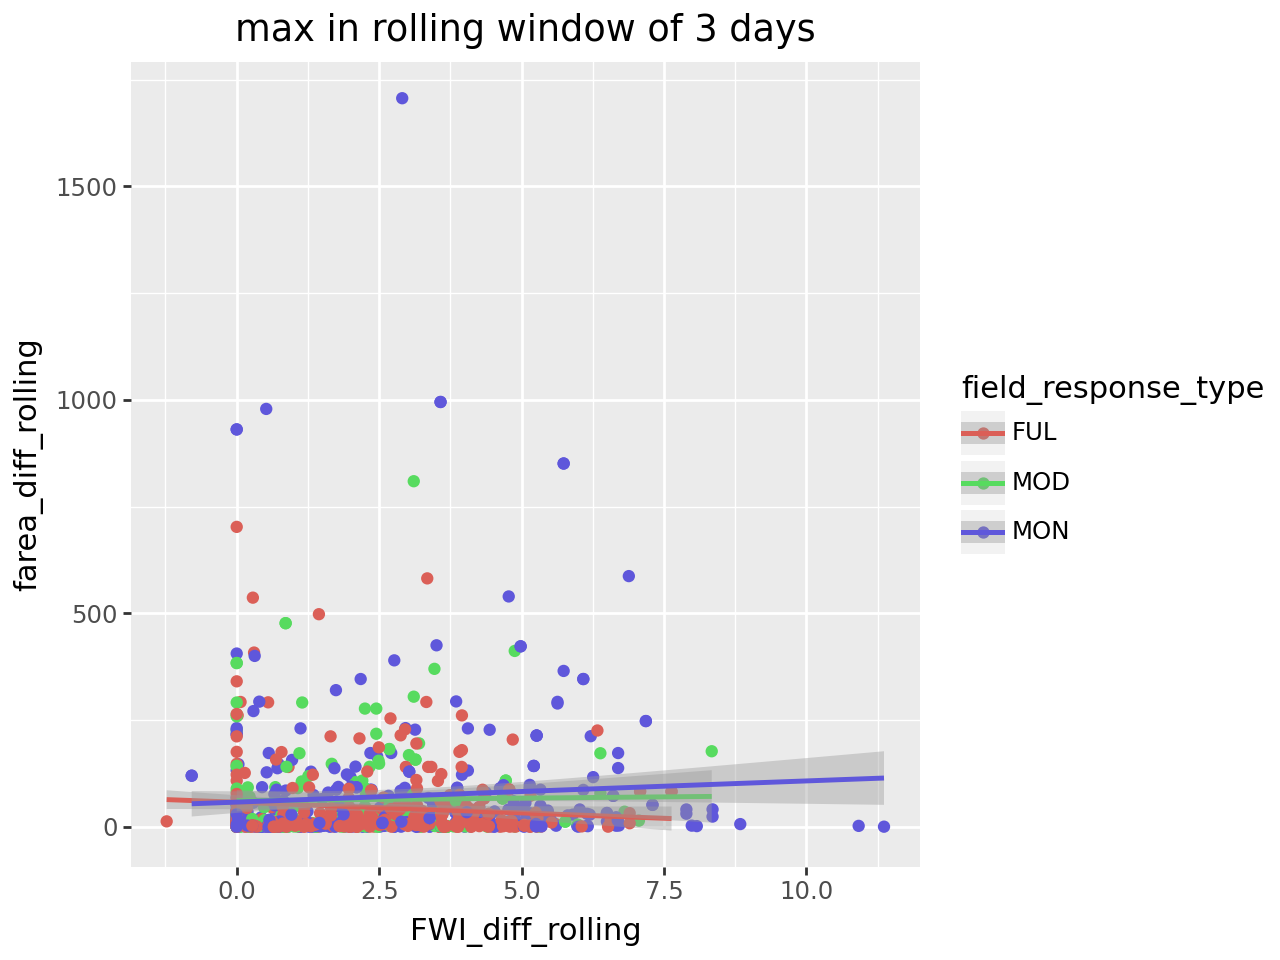

<ggplot: (640 x 480)>


/srv/conda/envs/notebook/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 179 rows containing missing values.


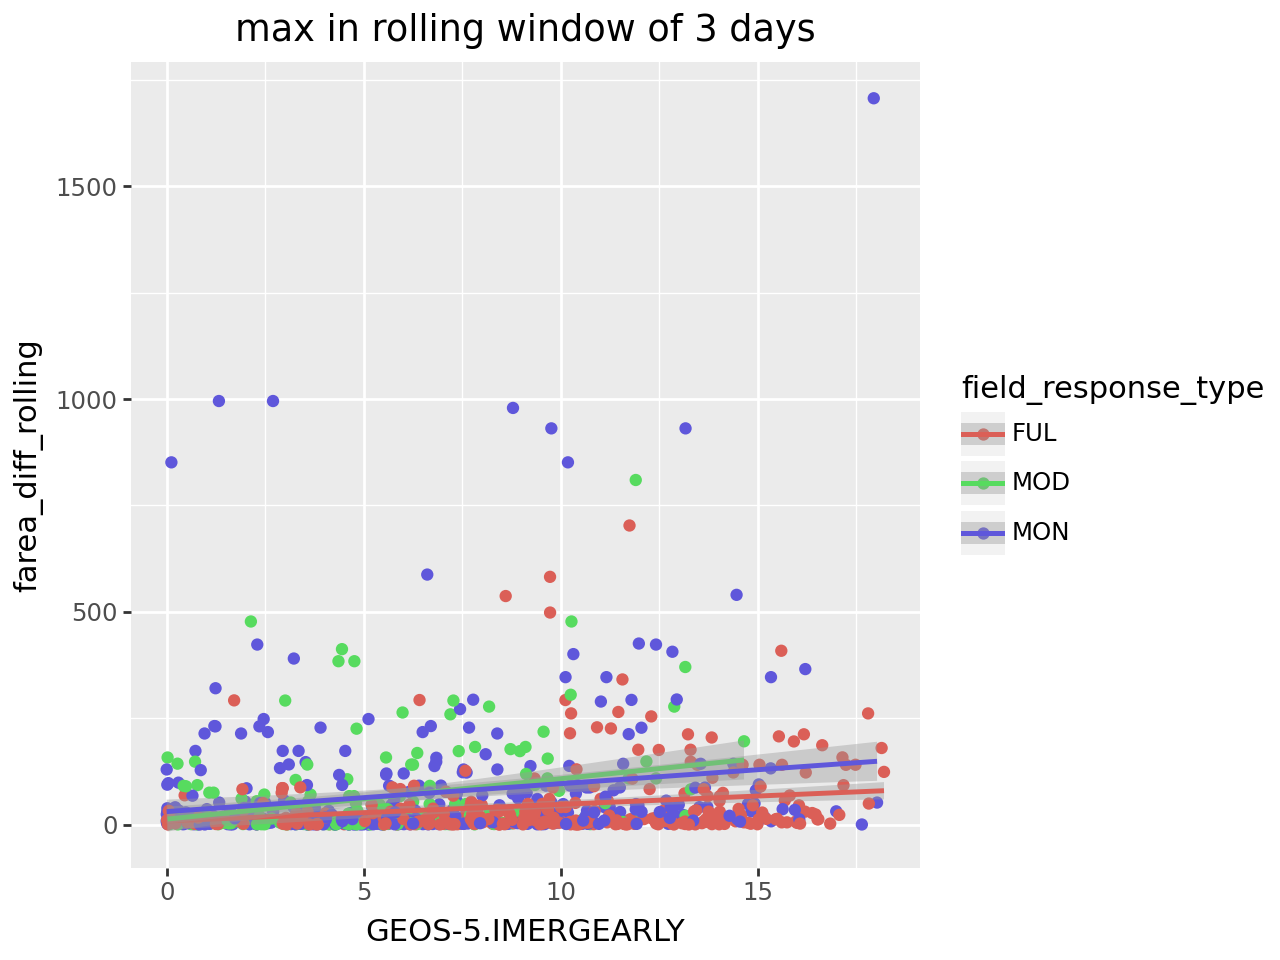

<ggplot: (640 x 480)>


/srv/conda/envs/notebook/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 179 rows containing missing values.


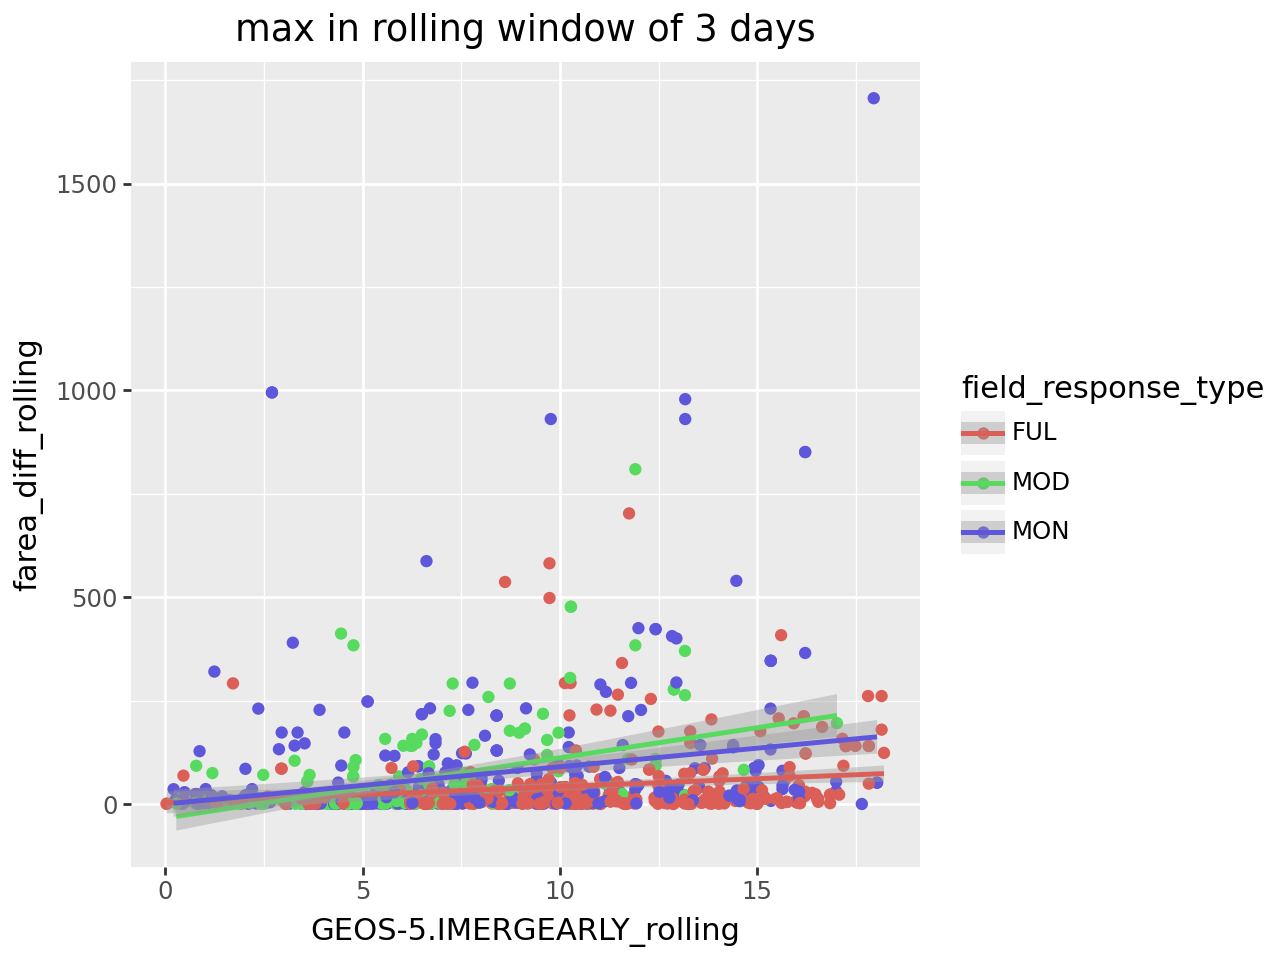

<ggplot: (640 x 480)>


In [12]:
#import numpy as np
from matplotlib import pyplot as plt
from plotnine import ggplot, geom_point, geom_jitter, aes, stat_smooth, facet_wrap
import plotnine as plotnine

### Some useful vars to color by 
def assign_day_of_fire(df):
    df = df.sort_values(by = "t")
    df['day_of_fire'] = df.t.rank()
    #df['day_of_fire'] = df['day_of_fire'].astype("int64")
    return(df)


def get_max_duration(df):
    max_duration = df.duration.max()
    df["max_duration"] = max_duration


fire3 = fire3.groupby("fireID").apply(assign_day_of_fire).reset_index(drop = True)
fire3["farea_shifted"] = fire3.groupby("fireID").farea.shift(periods = 1)

fire3["normalized_farea_diff"] = fire3.farea_diff/fire3.farea_shifted

rolling_num = 3
agg_function = "max" # max

fire3["FWI_rolling"] = fire3.groupby("fireID").FWI.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3["FWI_norm_rolling"] = fire3.groupby("fireID").FWI_norm.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3["FWI_diff_rolling"] = fire3.groupby("fireID").FWI_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3['farea_rolling'] = fire3.groupby("fireID").farea.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3['farea_diff_rolling'] = fire3.groupby("fireID").farea_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3["GEOS-5.IMERGEARLY_rolling"] = fire3.groupby("fireID")["GEOS-5.IMERGEARLY"].rolling(rolling_num).agg(agg_function).reset_index(drop = True)

long_fires = fire3[fire3.day_of_fire > 3].fireID.unique()
#fire3['max_dof'] = fire3.groupby("fireID").day_of_fire.max()

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)

#x_var = ["FWI","FWI_rolling", "FWI_diff_rolling", "FWI_norm_rolling"]
#y_var = ['farea', "normalized_farea_diff", 'farea_rolling', 'farea_diff_rolling']


x_var = ["FWI","FWI_rolling", "FWI_diff_rolling", "GEOS-5.IMERGEARLY", "GEOS-5.IMERGEARLY_rolling"]
y_var = [ 'farea_diff_rolling']

for x in x_var:
    for y in y_var:
        #p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = 'field_latitude'))
        p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "field_response_type"))
        #p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "farea_shifted"))
         + geom_point()
         + plotnine.labels.ylab(y)
         + plotnine.labels.xlab(x)
         + stat_smooth(method = "glm", formula = "y ~ x")
         #+ plotnine.scale_y_log10()
         + plotnine.ggtitle(f"{agg_function} in rolling window of {rolling_num} days")

         )
        p.show()
        print(p)
        #del(p)

        
        

## Trying to narrow things down to just publication-level figures. 

In [8]:
# fire3.columns



fire3["GEOS5_IMERGEARLY_rolling"] = fire3["GEOS-5.IMERGEARLY_rolling"]

fire3["log_farea_diff_rolling"] = np.log(fire3["farea_diff_rolling"] + 0.999)

KeyError: 'GEOS-5.IMERGEARLY_rolling'

In [ ]:
#zip_model = sm.ZeroInflatedPoisson.from_formula(formula, data=df, inflation='probit').fit()
#print(zip_model.summary())

In [15]:
# print(zip_model.aic)

# ?sm.ZeroInflatedPoisson

In [17]:
### Need to implement a color bar for fill_between
# rgb_values.reverse()
# rgb_values

#pretty_names = {c: "Response Type", "MON": "Monitored", "FUL": "Full Supression", "MOD": "Modified Supression"}

#fire3.field_response_type.map(pretty_names).unique()

In [74]:
#test = fire3.groupby("fireID").apply(get_max_duration, include_groups=True)
#test


/tmp/ipykernel_2144/347974932.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [18]:
#dur_fr = fire3.groupby("fireID").duration.max().reset_index(drop=False)

#long_fires = dur_fr[dur_fr.duration >= 3].fireID

array(['FUL', 'MOD', 'MON'], dtype=object)

In [11]:
# fid = "1088"

# m = fire3.to_crs("4326")[(fire3.fireID == fid) & (fire3.t == '2023-06-22 12:00:00')][['fireID', 't',
#        'field_agency_fire_id', 
#        'field_situation_report_date', 
#        'field_system_fire_cause', 'field_response_type', 'geometry'] ].explore(style_kwds = {"facecolor": None, "alpha": 0.7})

# tmp = fire3.to_crs(4326)[(fire3.fireID == fid) & (fire3.t == '2023-06-22 12:00:00')][['fireID', 't',
#        'field_agency_fire_id', 'field_situation_report_date', 
#        'field_system_fire_cause', 'field_response_type', 'field_latitude', 'field_longitude'] ]#.explore(style_kwds = {"facecolor": None, "alpha": 0.7})
# tmp = gpd.GeoDataFrame(tmp, geometry = gpd.points_from_xy(tmp.field_longitude, tmp.field_latitude), crs = "4326")

# tmp.explore(m = m, color = "red",  style_kwds = {"facecolor": None, "alpha": 0.7})

Text(0.5, 1.0, 'Fire area difference Full Response')

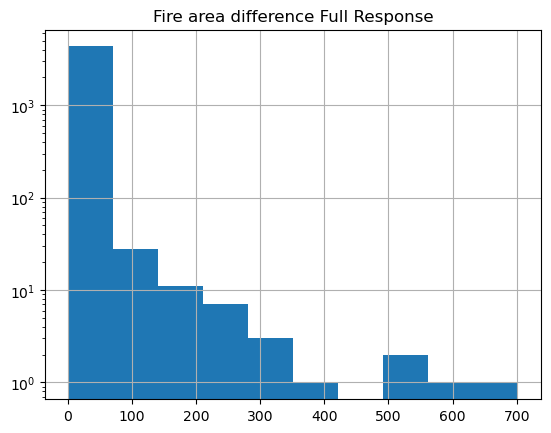

In [ ]:
fire3[fire3.field_response_type == 'FUL'].farea_diff.hist()
plt.yscale("log")
plt.title("Fire area difference Full Response")

Text(0.5, 1.0, 'Fire area difference MOD Response')

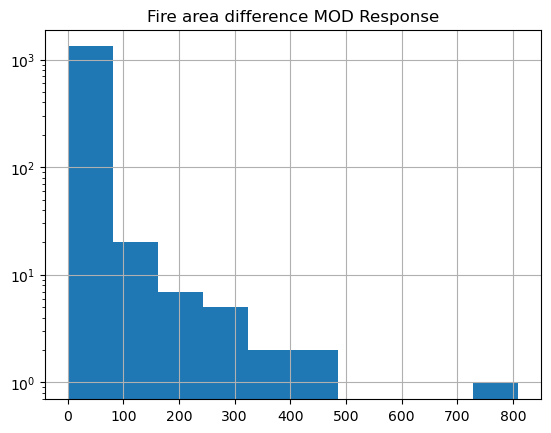

In [114]:
fire3[fire3.field_response_type == 'MOD'].farea_diff.hist()
plt.yscale("log")
plt.title("Fire area difference MOD Response")

Text(0.5, 1.0, 'Fire area difference MON Response')

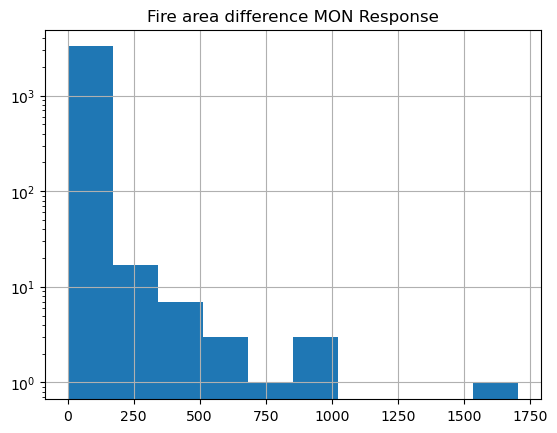

In [115]:
fire3[fire3.field_response_type == 'MON'].farea_diff.hist()
plt.yscale("log")
plt.title("Fire area difference MON Response")

farea_diff_rolling ~ GEOS5_IMERGEARLY_rolling:C(field_response_type)
                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  928
Model:                            GLM   Df Residuals:                      924
Model Family:                Gaussian   Df Model:                            3
Link Function:                    Log   Scale:                          14835.
Method:                          IRLS   Log-Likelihood:                -5771.4
Date:                Wed, 13 Nov 2024   Deviance:                   1.3708e+07
Time:                        19:39:16   Pearson chi2:                 1.37e+07
No. Iterations:                    10   Pseudo R-squ. (CS):             0.1059
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


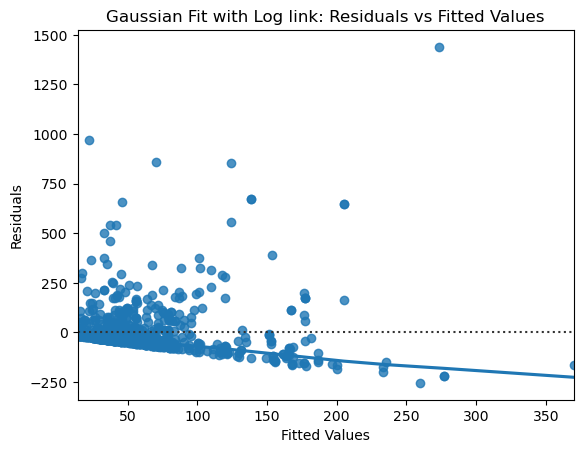

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


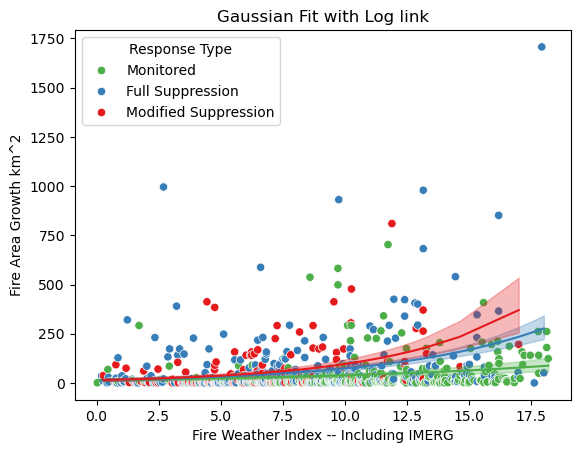

                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  928
Model:                            GLM   Df Residuals:                      924
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                          15193.
Method:                          IRLS   Log-Likelihood:                -5782.4
Date:                Wed, 13 Nov 2024   Deviance:                   1.4038e+07
Time:                        19:39:22   Pearson chi2:                 1.40e+07
No. Iterations:                     3   Pseudo R-squ. (CS):            0.08229
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


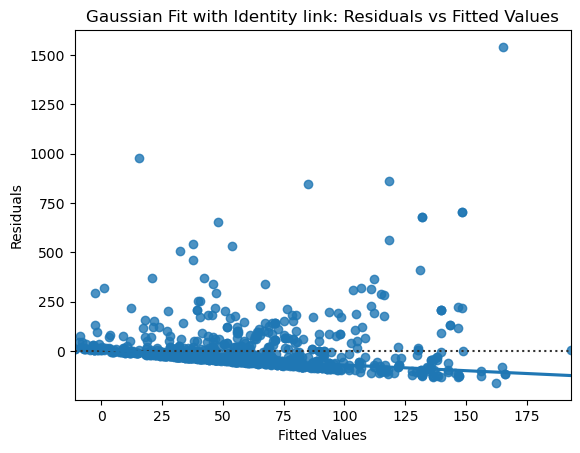

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


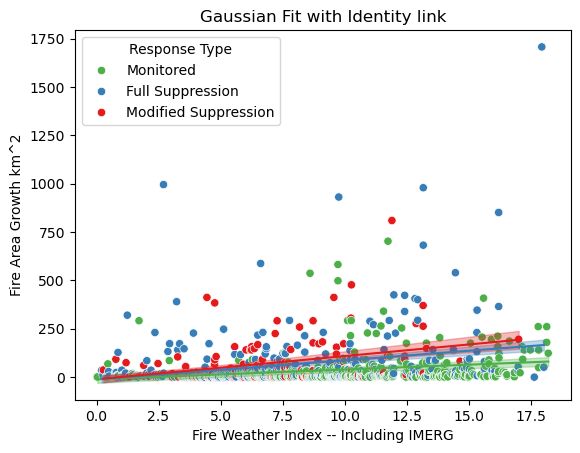

                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  928
Model:                            GLM   Df Residuals:                      924
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                          4.6950
Method:                          IRLS   Log-Likelihood:                -4500.7
Date:                Wed, 13 Nov 2024   Deviance:                       2568.8
Time:                        19:39:27   Pearson chi2:                 4.34e+03
No. Iterations:                    16   Pseudo R-squ. (CS):            0.05719
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


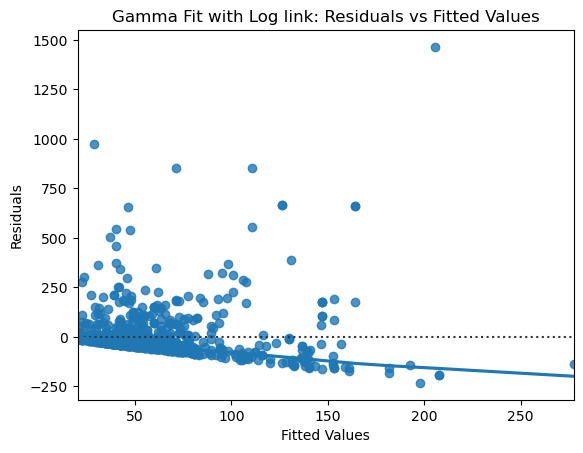

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


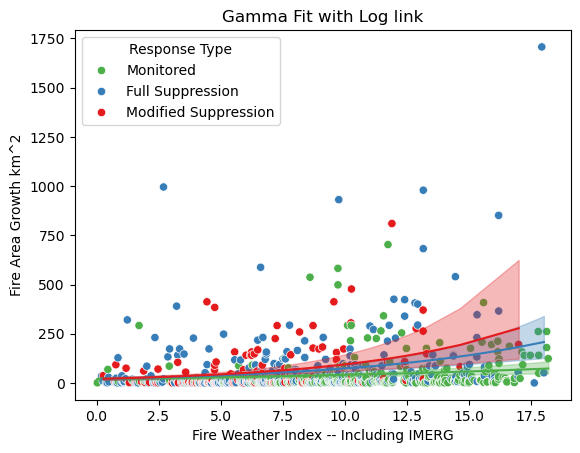

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  928
Model:                            GLM   Df Residuals:                      924
Model Family:                   Gamma   Df Model:                            3
Link Function:               Identity   Scale:                          4.4498
Method:                          IRLS   Log-Likelihood:                -4483.8
Date:                Wed, 13 Nov 2024   Deviance:                       2605.5
Time:                        19:39:33   Pearson chi2:                 4.11e+03
No. Iterations:                    37   Pseudo R-squ. (CS):            0.05185
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

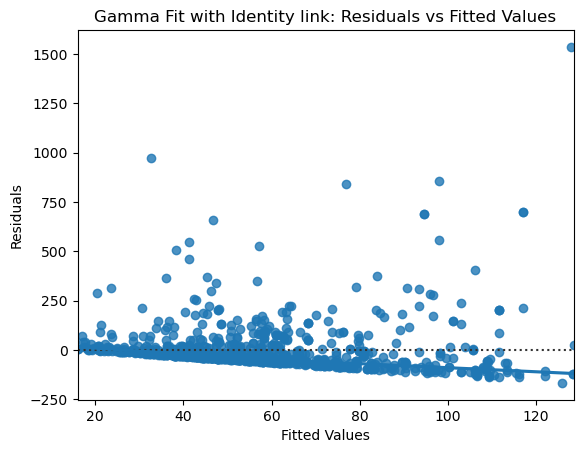

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


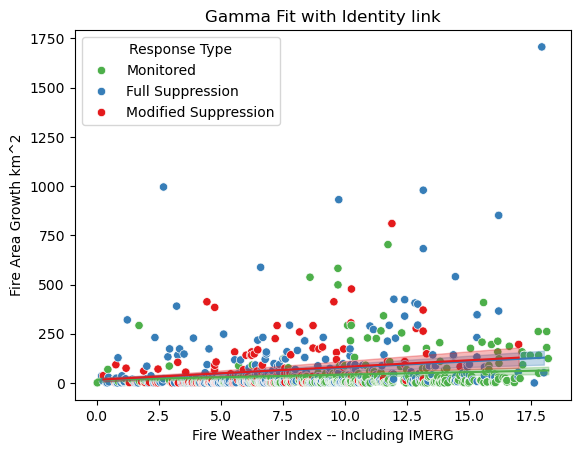

                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  928
Model:                            GLM   Df Residuals:                      924
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -54918.
Date:                Wed, 13 Nov 2024   Deviance:                   1.0570e+05
Time:                        19:39:38   Pearson chi2:                 2.07e+05
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


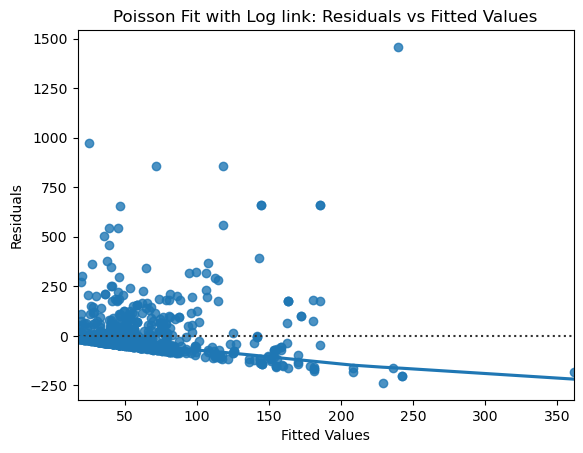

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


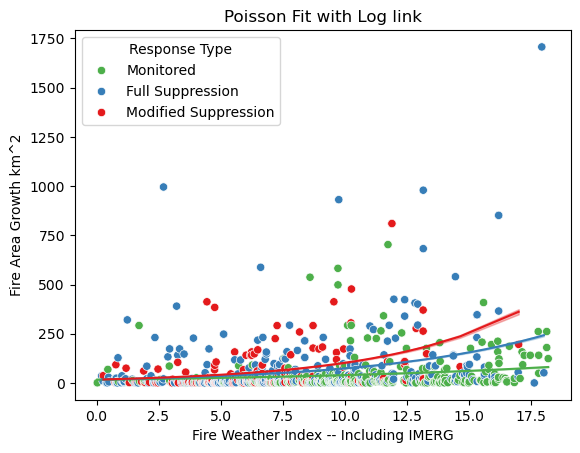

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Poisson family.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  928
Model:                            GLM   Df Residuals:                      924
Model Family:                 Poisson   Df Model:                            3
Link Function:               Identity   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -56729.
Date:                Wed, 13 Nov 2024   Deviance:                   1.0933e+05
Time:                        19:39:44   Pearson chi2:                 2.11e+05
No. Iterations:                    17   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

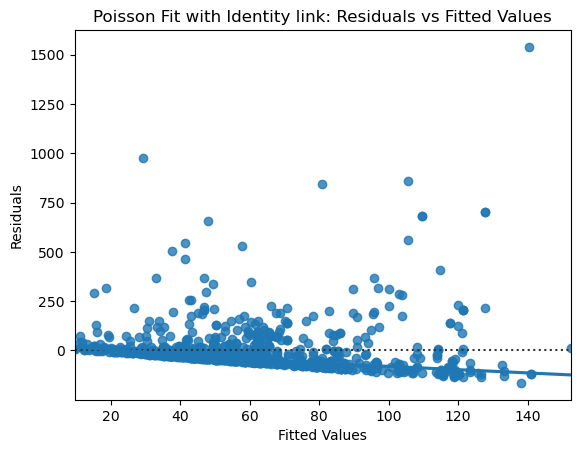

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


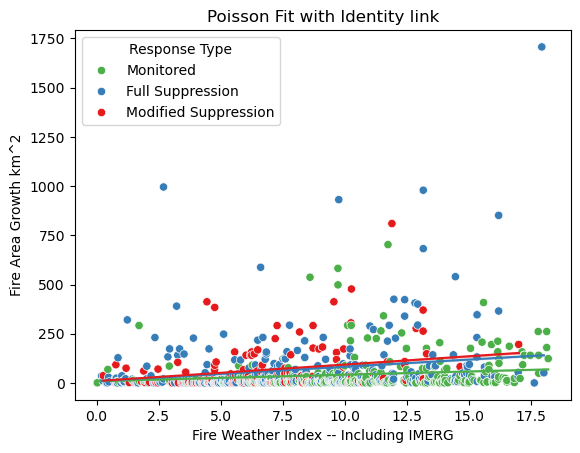

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  928
Model:                            GLM   Df Residuals:                      924
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4593.4
Date:                Wed, 13 Nov 2024   Deviance:                       2336.3
Time:                        19:39:49   Pearson chi2:                 4.23e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2384
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

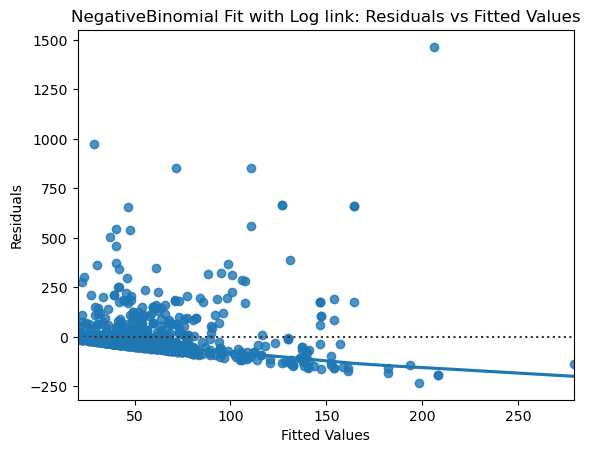

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


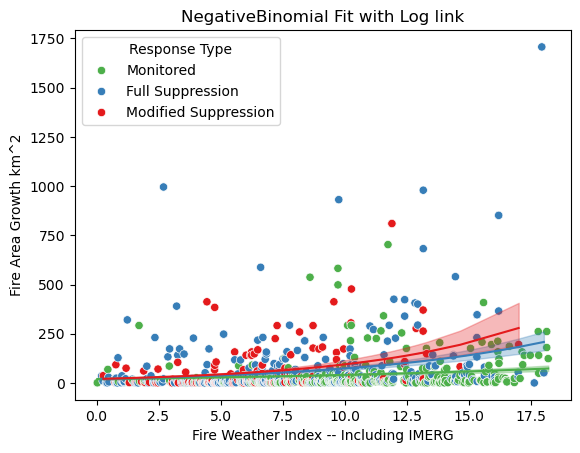

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the NegativeBinomial family.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  928
Model:                            GLM   Df Residuals:                      924
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:               Identity   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4611.6
Date:                Wed, 13 Nov 2024   Deviance:                       2372.6
Time:                        19:39:54   Pearson chi2:                 4.02e+03
No. Iterations:                    17   Pseudo R-squ. (CS):             0.2079
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

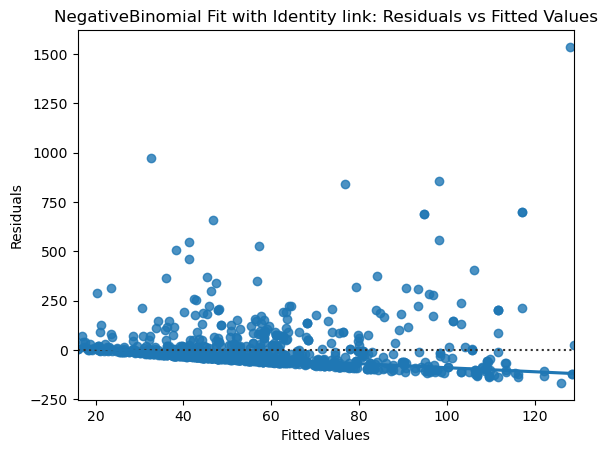

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


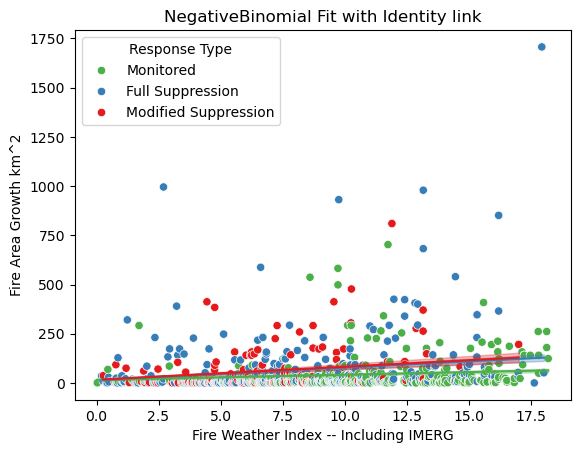

In [102]:
### Trying to fit a glm for non-constant varience 
from patsy import ModelDesc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires))  #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)
#row_mask = (~fire3.fireID.str.contains("_")) 

df = fire3[row_mask]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling"]].dropna()




y = "farea_diff_rolling"
x = "GEOS5_IMERGEARLY_rolling"
c = "field_response_type"

pretty_names = {c: "Response Type", "MON": "Monitored", "FUL": "Full Supression", "MOD": "Modified Supression"}

# Unique category labels: 'D', 'F', 'G', ...
color_labels = df[c].unique()

# List of RGB triplets
rgb_values = sns.color_palette("Set1", 3)
rgb_values.reverse()

# Map label to RGB
color_map = dict(zip(color_labels, rgb_values))

# # Finally use the mapped values
# plt.scatter(df['carat'], df['price'], c=df[c].map(color_map))


formula = f"{y} ~ {x}:C({c})"
print(formula)

families = ["Gaussian", "Gamma", "Poisson", "NegativeBinomial"]
links = ["Log", "Identity"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response
        df = df.sort_values(by = x)
        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        
    
        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df, hue = c, palette = color_map) #facet_kws={'legend_out': True}
        
        handles, labels = actual.get_legend_handles_labels()

        # Customize legend titles and labels
        actual.legend(handles=handles, labels=[ "Monitored", "Full Suppression", "Modified Suppression"], title=pretty_names[c])
        # actual._legend.set_title(pretty_names[c])
        #  # replace labels
        # for t, l in zip(actual._legend.texts, df.field_response_type.map(pretty_names).unique()):
        #     t.set_text(l)
        #Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, hue =c, legend = False, palette = color_map)
        pred
        # Plot the confidence intervals
        for cat in df[c].unique():
            #print(cat)
            #print(df.loc[(df[c] == cat), [c]].map(color_map))
            plt.fill_between(df.loc[(df[c] == cat)][x], df.loc[(df[c] == cat)]['conf_int_low'], df.loc[(df[c] == cat)]['conf_int_high'],  color=color_map[cat], alpha=0.3)

        plt.title(f'{f} Fit with {l} link')
        plt.xlabel("Fire Weather Index -- Including IMERG")
        plt.ylabel("Fire Area Growth km^2")

        #plt.legend(title = pretty_names[c], labels = df.field_response_type.map(pretty_names).unique())
        plt.savefig(f'{os.path.abspath("some_figs/")}/model_fit_{f}_with_{l}_{y}_func_of_{x}_by_{c}_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
  

## Find the lowest BIC score of the bunch

In [43]:


stats = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})
stats




,Family,Link_Function,Log_Likelyhood,AIC,BIC
0,Gaussian,Log,-5811.1,11630.213214,1.474256e+07
1,Gaussian,Identity,-5821.3,11650.574305,1.506952e+07
2,Gamma,Log,-4555.4,9118.756707,-3.684842e+03
3,Gamma,Identity,-4532.6,9073.255183,-3.658217e+03
4,Poisson,Log,-57882.,115771.032648,1.052950e+05
5,Poisson,Identity,-59440.,118887.182728,1.084111e+05
6,NegativeBinomial,Log,-4639.1,9286.280210,-3.920213e+03
7,NegativeBinomial,Identity,-4652.4,9312.758195,-3.893735e+03


In [44]:
print(stats[stats.Log_Likelyhood.astype("float").min() == stats.Log_Likelyhood.astype("float") ])

print(stats[stats.AIC.astype("float").min() == stats.AIC.astype("float") ])
print(stats[stats.BIC.astype("float").min() == stats.BIC.astype("float") ])



    Family Link_Function Log_Likelyhood            AIC            BIC
5  Poisson      Identity        -59440.  118887.182728  108411.102302
  Family Link_Function Log_Likelyhood          AIC          BIC
3  Gamma      Identity        -4532.6  9073.255183 -3658.216825
             Family Link_Function Log_Likelyhood         AIC          BIC
6  NegativeBinomial           Log        -4639.1  9286.28021 -3920.213072


farea_diff_rolling ~ FWI_rolling:C(field_response_type)
                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      925
Model Family:                Gaussian   Df Model:                            3
Link Function:                    Log   Scale:                          16407.
Method:                          IRLS   Log-Likelihood:                -5824.4
Date:                Wed, 13 Nov 2024   Deviance:                   1.5176e+07
Time:                        19:02:17   Pearson chi2:                 1.52e+07
No. Iterations:                    13   Pseudo R-squ. (CS):            0.06561
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


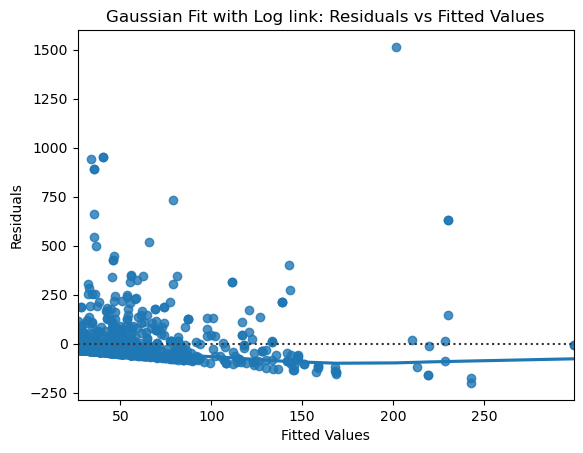

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


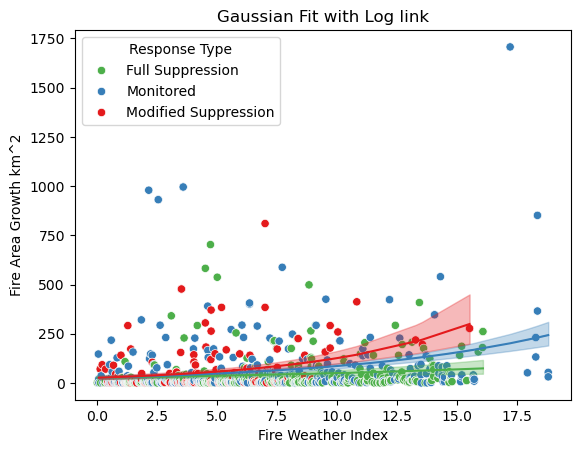

                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      925
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                          16672.
Method:                          IRLS   Log-Likelihood:                -5831.8
Date:                Wed, 13 Nov 2024   Deviance:                   1.5422e+07
Time:                        19:02:22   Pearson chi2:                 1.54e+07
No. Iterations:                     3   Pseudo R-squ. (CS):            0.04966
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


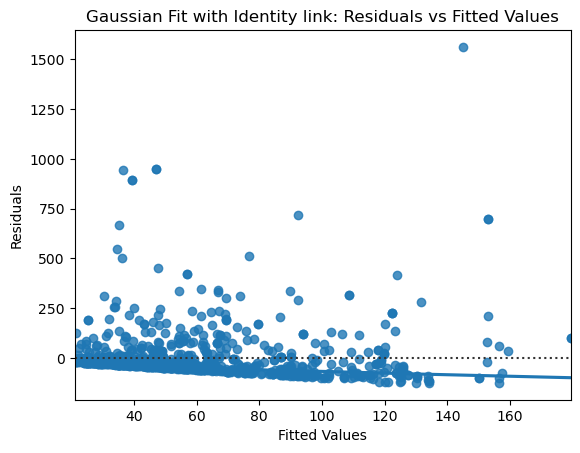

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


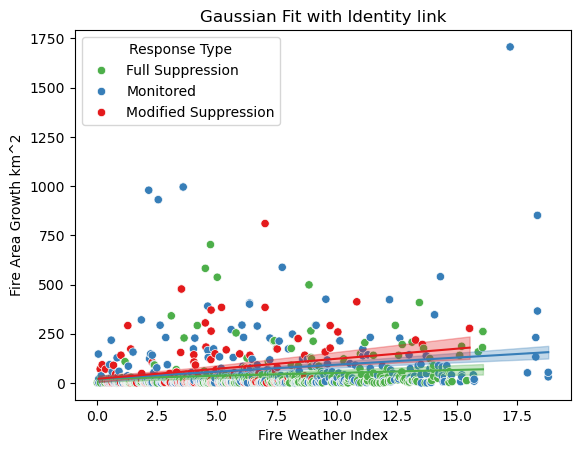

                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      925
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                          5.1646
Method:                          IRLS   Log-Likelihood:                -4568.2
Date:                Wed, 13 Nov 2024   Deviance:                       2713.9
Time:                        19:02:28   Pearson chi2:                 4.78e+03
No. Iterations:                    14   Pseudo R-squ. (CS):            0.03011
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


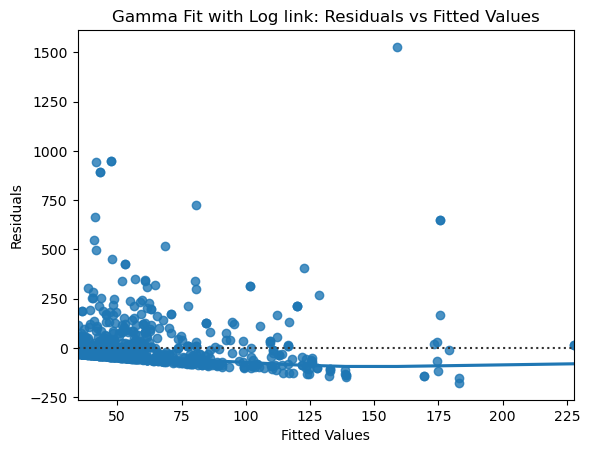

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


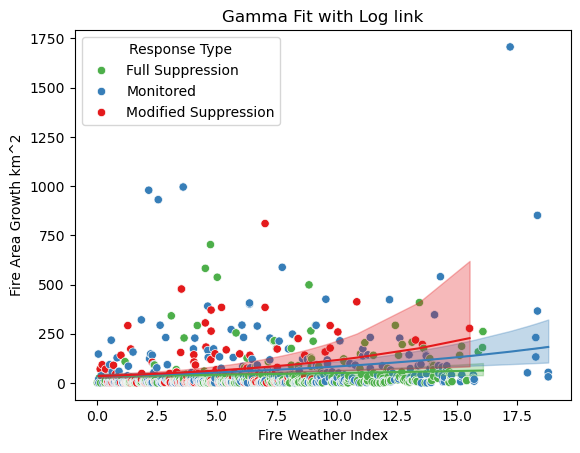

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      925
Model Family:                   Gamma   Df Model:                            3
Link Function:               Identity   Scale:                          5.0807
Method:                          IRLS   Log-Likelihood:                -4561.7
Date:                Wed, 13 Nov 2024   Deviance:                       2718.2
Time:                        19:02:33   Pearson chi2:                 4.70e+03
No. Iterations:                    16   Pseudo R-squ. (CS):            0.02972
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

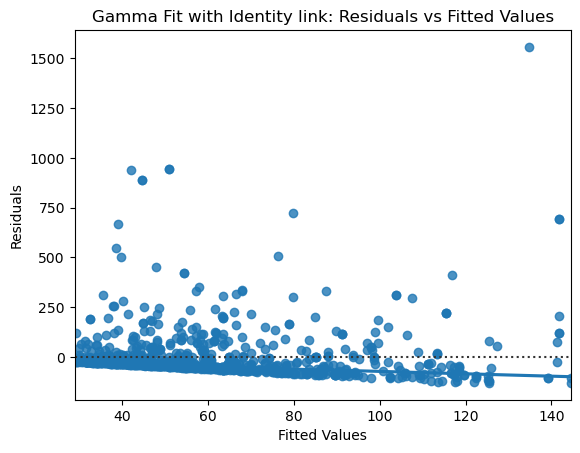

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


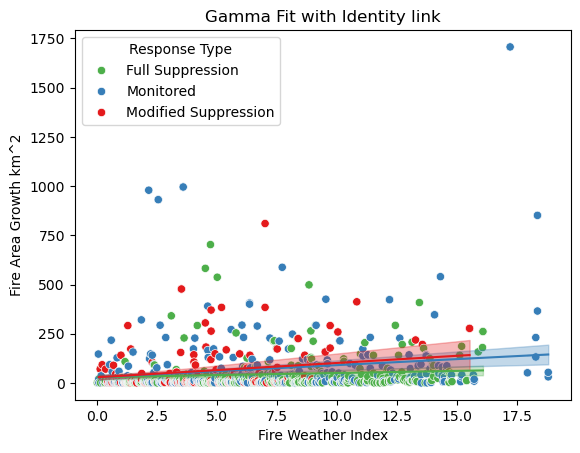

                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      925
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -60724.
Date:                Wed, 13 Nov 2024   Deviance:                   1.1730e+05
Time:                        19:02:38   Pearson chi2:                 2.51e+05
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


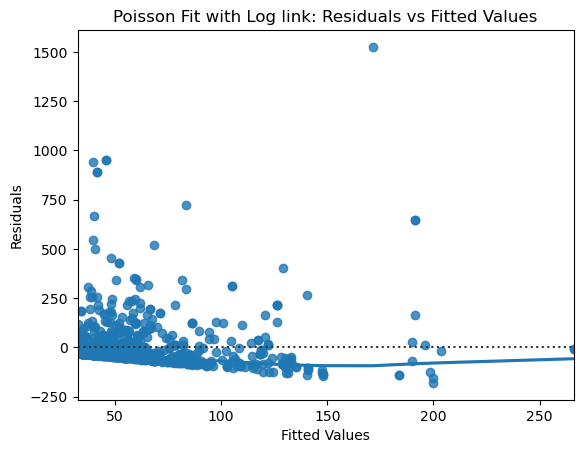

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


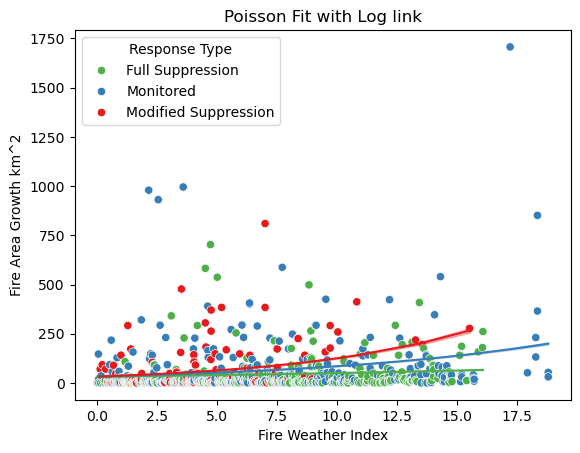

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Poisson family.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      925
Model Family:                 Poisson   Df Model:                            3
Link Function:               Identity   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -61385.
Date:                Wed, 13 Nov 2024   Deviance:                   1.1862e+05
Time:                        19:02:43   Pearson chi2:                 2.50e+05
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

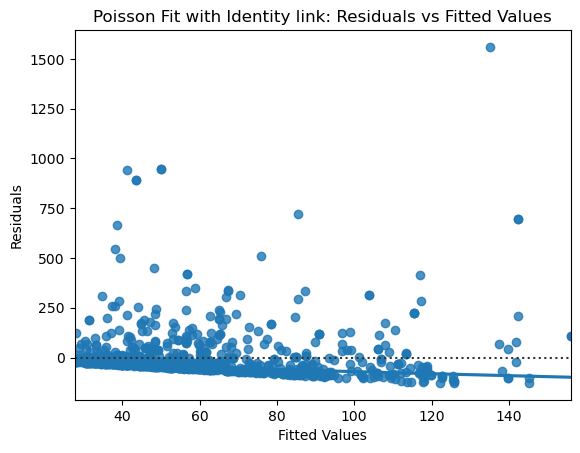

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


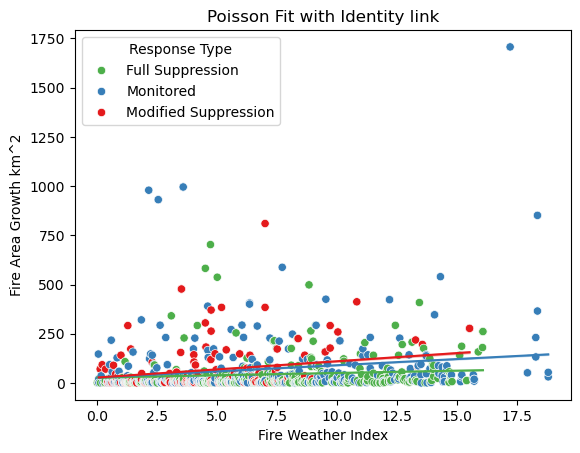

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      925
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4677.2
Date:                Wed, 13 Nov 2024   Deviance:                       2477.4
Time:                        19:02:48   Pearson chi2:                 4.68e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.1441
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

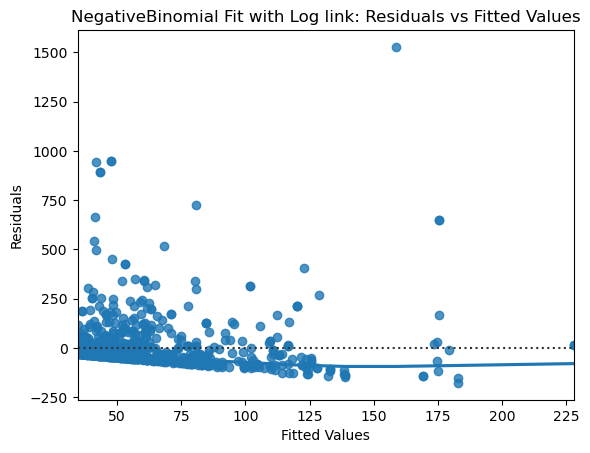

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


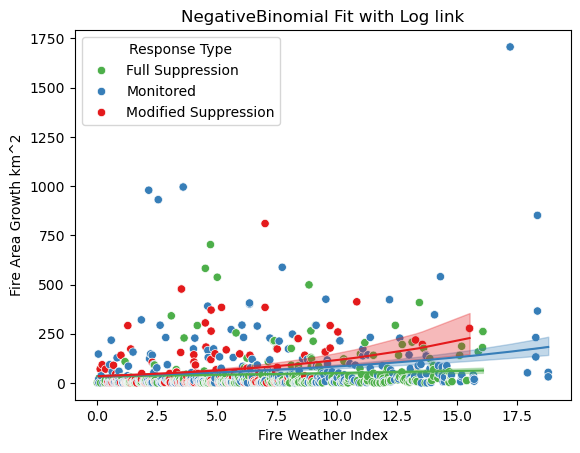

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the NegativeBinomial family.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      925
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:               Identity   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4679.4
Date:                Wed, 13 Nov 2024   Deviance:                       2481.8
Time:                        19:02:53   Pearson chi2:                 4.60e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1400
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

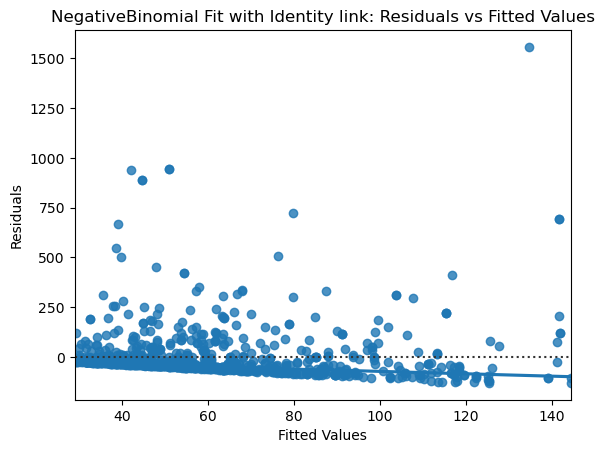

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


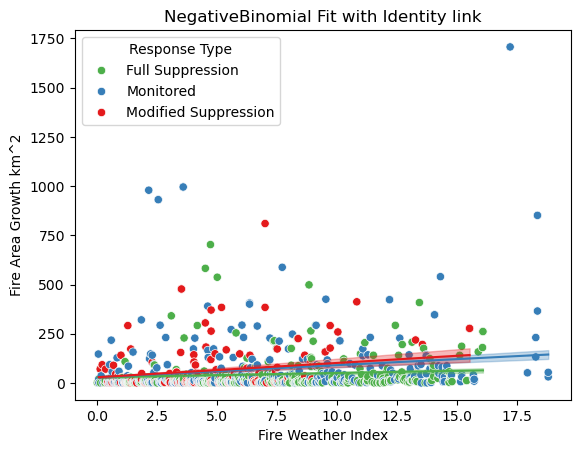

    Family Link_Function Log_Likelyhood            AIC           BIC
5  Poisson      Identity        -61385.  122777.241036  112301.16061
  Family Link_Function Log_Likelyhood          AIC          BIC
3  Gamma      Identity        -4561.7  9131.379901 -3603.376864
             Family Link_Function Log_Likelyhood          AIC          BIC
6  NegativeBinomial           Log        -4677.2  9362.370139 -3844.123143


,Family,Link_Function,Log_Likelyhood,AIC,BIC
0,Gaussian,Log,-5824.4,11656.743396,1.516983e+07
1,Gaussian,Identity,-5831.8,11671.652271,1.541549e+07
2,Gamma,Log,-4568.2,9144.342904,-3.607656e+03
3,Gamma,Identity,-4561.7,9131.379901,-3.603377e+03
4,Poisson,Log,-60724.,121455.592876,1.109795e+05
5,Poisson,Identity,-61385.,122777.241036,1.123012e+05
6,NegativeBinomial,Log,-4677.2,9362.370139,-3.844123e+03
7,NegativeBinomial,Identity,-4679.4,9366.767751,-3.839726e+03


In [20]:
### Looking at only the GEOS-5

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)
#row_mask = (~fire3.fireID.str.contains("_")) 

df = fire3[row_mask]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling"]].dropna()

y = "farea_diff_rolling"
x = "FWI_rolling"
c = "field_response_type"
#df = df.sort_values(by = x)

# Unique category labels: 'D', 'F', 'G', ...
# color_labels = df[c].unique()

# # List of RGB triplets

# #rgb_values = sns.color_palette("Set1", 3)
# #rgb_values.reverse()

# # Map label to RGB
# color_map = dict(zip(color_labels, rgb_values))

formula = f"{y} ~ {x}:C({c})"
print(formula)

families = ["Gaussian", "Gamma", "Poisson", "NegativeBinomial"]
links = ["Log", "Identity"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response
        df = df.sort_values(by = x)
        
        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df, hue = c, palette= color_map) # hue = c)
        actual
        handles, labels = actual.get_legend_handles_labels()

        # Customize legend titles and labels
        actual.legend(handles=handles, labels=[ "Full Suppression", "Monitored", "Modified Suppression"], title=pretty_names[c])
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, hue = c, palette= color_map, legend = False) #  hue =c,
        pred
        # Plot the confidence intervals
        for cat in df[c].unique():
            #print(cat)
            #print(df.loc[(df[c] == cat), [c]].map(color_map))
            plt.fill_between(df.loc[(df[c] == cat)][x], df.loc[(df[c] == cat)]['conf_int_low'], df.loc[(df[c] == cat)]['conf_int_high'],  color=color_map[cat], alpha=0.3)

        plt.title(f'{f} Fit with {l} link')
        plt.xlabel("Fire Weather Index")
        plt.ylabel("Fire Area Growth km^2")
        #plt.legend()
        plt.savefig(f'{os.path.abspath("some_figs/")}/model_fit_{f}_with_{l}_{y}_func_of_{x}_by_{c}_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})


print(stats_fwi_rolling[stats_fwi_rolling.Log_Likelyhood.astype("float").min() == stats_fwi_rolling.Log_Likelyhood.astype("float") ])

print(stats_fwi_rolling[stats_fwi_rolling.AIC.astype("float").min() == stats_fwi_rolling.AIC.astype("float") ])
print(stats_fwi_rolling[stats_fwi_rolling.BIC.astype("float").min() == stats_fwi_rolling.BIC.astype("float") ])
stats_fwi_rolling

### Comparing individual models to single-fit model. 

farea_diff_rolling ~ GEOS5_IMERGEARLY_rolling
                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      927
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4683.3
Date:                Wed, 13 Nov 2024   Deviance:                       2489.6
Time:                        19:02:58   Pearson chi2:                 4.55e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1328
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


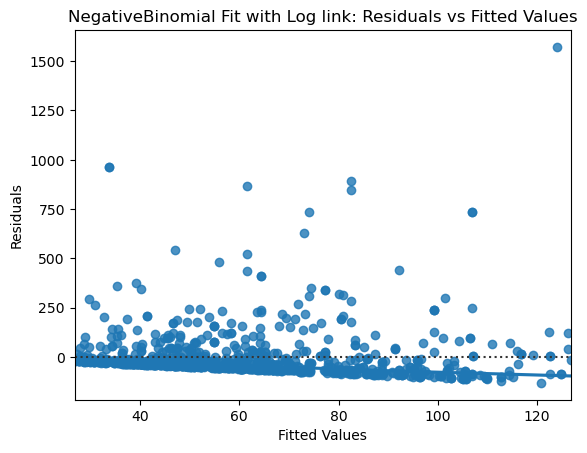

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


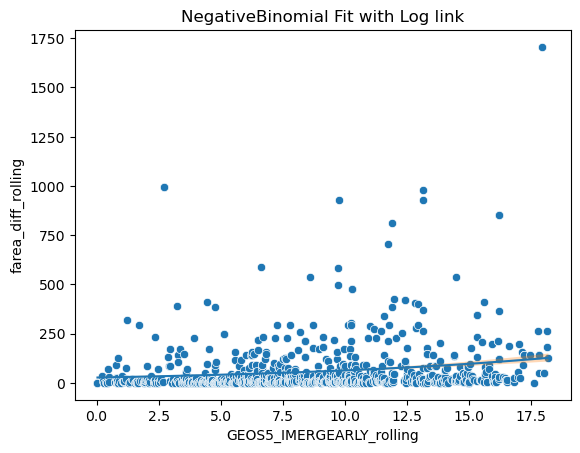

NameError: name 'stats' is not defined

In [21]:
############ GEO5-5 and IMERGE #################


row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)
#row_mask = (~fire3.fireID.str.contains("_")) 

df = fire3[row_mask]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling"]].dropna()

y = "farea_diff_rolling"
x = "GEOS5_IMERGEARLY_rolling"
c = "field_response_type"


formula = f"{y} ~ {x}"
print(formula)

families = ["NegativeBinomial"] ### Chosen based on BIC (and AIC)
links = ["Log"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)

    

        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response
        df = df.sort_values(by = x)
        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df)
        actual
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, legend = False)
        pred
        # Plot the confidence intervals
        plt.fill_between(df[x], df['conf_int_low'], df['conf_int_high'], alpha=0.3)

        plt.title(f'{f} Fit with {l} link')
        plt.xlabel(x)
        plt.ylabel(y)
        #plt.legend()
        plt.savefig(f'{os.path.abspath("some_figs/")}/model_fit_{f}_with_{l}_{y}_func_of_{x}_ONLY_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_single_model_imerge = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})

print(f"The model with supression had a BIC of: {stats.BIC.min()}. The model without supression had a BIC of: {stats_single_model_imerge.BIC.min()}")



stats_single_model_imerge

In [ ]:

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)
#row_mask = (~fire3.fireID.str.contains("_")) 

df = fire3[row_mask]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling"]].dropna()

y = "farea_diff_rolling"
x = "FWI_rolling"
c = "field_response_type"


formula = f"{y} ~ {x}"
print(formula)

families = ["NegativeBinomial"] ### Chosen based on BIC (and AIC)
links = ["Identity"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response

        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T
        df = df.sort_values(by = x)

        actual = sns.scatterplot(x=x, y=y, data=df)
        actual
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, legend = False)
        pred
        # Plot the confidence intervals
        #plt.fill_between(df['FWI_rolling'], df['conf_int_low'], df['conf_int_high'], c ="field_response_type", alpha=0.3)
        
        plt.fill_between(df['FWI_rolling'], df['conf_int_low'], df['conf_int_high'], alpha=0.3)

        plt.title(f'{f} Fit with {l} link')
        plt.xlabel(x)
        plt.ylabel(y)
        #plt.legend()
        plt.savefig(f'/projects/old_shared/fire_weather_vis/Lightning_analysis/some_figs/model_fit_{f}_with_{l}_{y}_func_of_{x}_ONLY_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_single_model_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})

print(f"The model with supression had a BIC of: {stats_fwi_rolling.BIC.min()}. The model without supression had a BIC of: {stats_single_model_fwi_rolling.BIC.min()}")



stats_single_model_fwi_rolling

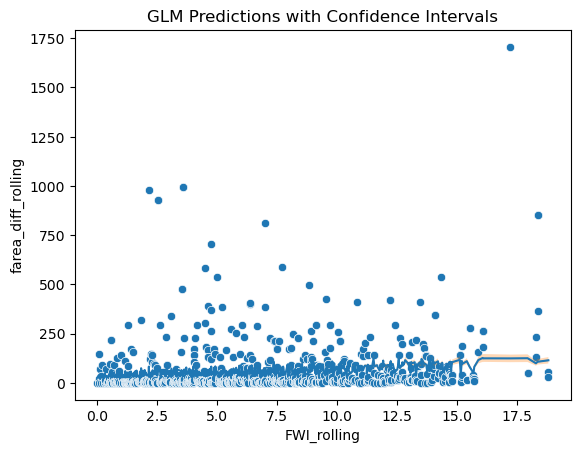

In [48]:
df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
       'field_response_type', 
       'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling",
       'fitted', 'residuals']].dropna()
predictions = model.get_prediction(df)
df['predicted'] = predictions.predicted_mean
df['conf_int_low'], df['conf_int_high'] = predictions.conf_int(method = "delta").T

df = df.sort_values(by = 'FWI_rolling')

actual = sns.scatterplot(x='FWI_rolling', y='farea_diff_rolling', data=df)
actual
# Plot the fitted values
pred = sns.lineplot(x='FWI_rolling', y='predicted', data=df, legend = False)
pred
# Plot the confidence intervals
plt.fill_between(df['FWI_rolling'], df['conf_int_low'], df['conf_int_high'], alpha=0.3)

plt.title('GLM Predictions with Confidence Intervals')
plt.xlabel('FWI_rolling')
plt.ylabel('farea_diff_rolling')
#plt.legend()
plt.show()

In [ ]:
#plt.scatter(df[x], df[y], hue = df[c])

#fire3.columns

## Plots of the best-fit models

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the NegativeBinomial family.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      925
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:               Identity   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4679.4
Date:                Tue, 12 Nov 2024   Deviance:                       2481.8
Time:                        15:39:54   Pearson chi2:                 4.60e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1400
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

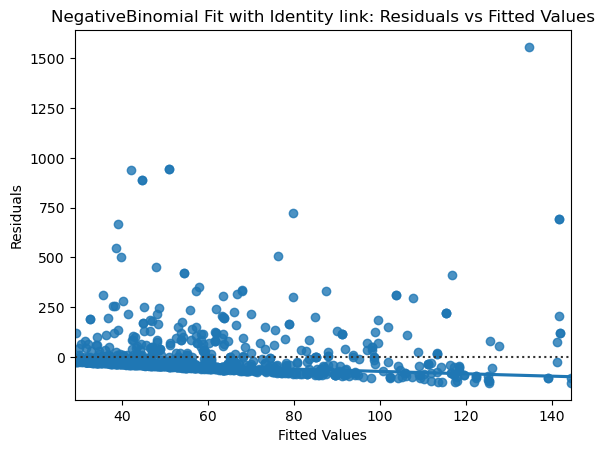

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


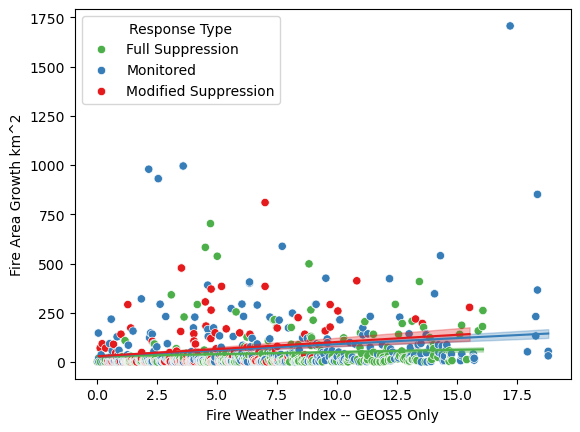

The model with supression had a BIC of: -3844.1231431064775. The model without supression had a BIC of: -3839.725531366689


In [50]:
#### GEOS-5 ONLY

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)
#row_mask = (~fire3.fireID.str.contains("_")) 

df = fire3[row_mask]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling"]].dropna()

y = "farea_diff_rolling"
x = "FWI_rolling"
c = "field_response_type"
#df = df.sort_values(by = x)

# Unique category labels: 'D', 'F', 'G', ...
# color_labels = df[c].unique()

# # List of RGB triplets

# #rgb_values = sns.color_palette("Set1", 3)
# #rgb_values.reverse()

# # Map label to RGB
# color_map = dict(zip(color_labels, rgb_values))

formula = f"{y} ~ {x}:C({c})"


families = ["NegativeBinomial"] ### Chosen based on BIC (and AIC)
links = ["Identity"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response
        df = df.sort_values(by = x)
        
        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df, hue = c, palette= color_map) # hue = c)
        actual
        handles, labels = actual.get_legend_handles_labels()

        # Customize legend titles and labels
        actual.legend(handles=handles, labels=[ "Full Suppression", "Monitored", "Modified Suppression"], title=pretty_names[c])
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, hue = c, palette= color_map, legend = False) #  hue =c,
        pred
        # Plot the confidence intervals
        for cat in df[c].unique():
            #print(cat)
            #print(df.loc[(df[c] == cat), [c]].map(color_map))
            plt.fill_between(df.loc[(df[c] == cat)][x], df.loc[(df[c] == cat)]['conf_int_low'], df.loc[(df[c] == cat)]['conf_int_high'],  color=color_map[cat], alpha=0.3)

        #plt.title(f'{f} Fit with {l} link')
        plt.title('')
        plt.xlabel("Fire Weather Index -- GEOS5 Only")
        plt.ylabel("Fire Area Growth km^2")
        #plt.legend()
        plt.savefig(f'{os.path.abspath("some_figs/")}/Pretty_model_fit_{f}_with_{l}_{y}_func_of_{x}_via_{c}_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_single_model_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})

print(f"The model with supression had a BIC of: {stats_fwi_rolling.BIC.min()}. The model without supression had a BIC of: {stats_single_model_fwi_rolling.BIC.min()}")

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  929
Model:                            GLM   Df Residuals:                      925
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4639.1
Date:                Tue, 12 Nov 2024   Deviance:                       2401.3
Time:                        16:18:40   Pearson chi2:                 4.61e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2114
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

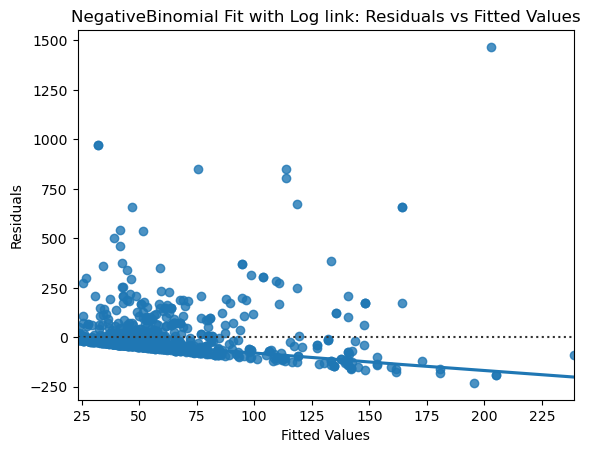

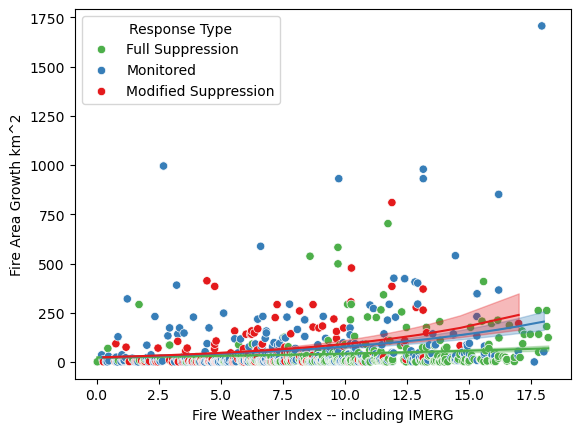

The model with supression had a BIC of: -3844.1231431064775. The model without supression had a BIC of: -3920.2130723044684


In [59]:
#### IMERG

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)
#row_mask = (~fire3.fireID.str.contains("_")) 

df = fire3[row_mask]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling"]].dropna()

y = "farea_diff_rolling"
x = "GEOS5_IMERGEARLY_rolling"
c = "field_response_type"
#df = df.sort_values(by = x)

# Unique category labels: 'D', 'F', 'G', ...
# color_labels = df[c].unique()

# # List of RGB triplets

# #rgb_values = sns.color_palette("Set1", 3)
# #rgb_values.reverse()

# # Map label to RGB
# color_map = dict(zip(color_labels, rgb_values))

formula = f"{y} ~ {x}:C({c})"


families = ["NegativeBinomial"] ### Chosen based on BIC (and AIC)
links = ["Log"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response
        df = df.sort_values(by = x)
        
        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df, hue = c, palette= color_map) # hue = c)
        actual
        handles, labels = actual.get_legend_handles_labels()

        # Customize legend titles and labels
        actual.legend(handles=handles, labels=[ "Full Suppression", "Monitored", "Modified Suppression"], title=pretty_names[c])
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, hue = c, palette= color_map, legend = False) #  hue =c,
        pred
        # Plot the confidence intervals
        for cat in df[c].unique():
            #print(cat)
            #print(df.loc[(df[c] == cat), [c]].map(color_map))
            plt.fill_between(df.loc[(df[c] == cat)][x], df.loc[(df[c] == cat)]['conf_int_low'], df.loc[(df[c] == cat)]['conf_int_high'],  color=color_map[cat], alpha=0.3)

        #plt.title(f'{f} Fit with {l} link')
        plt.title('')
        plt.xlabel("Fire Weather Index -- including IMERG")
        plt.ylabel("Fire Area Growth km^2")
        #plt.legend()
        #plt.savefig(f'{os.path.abspath("some_figs/")}/Pretty_model_fit_{f}_with_{l}_{y}_func_of_{x}_via_{c}_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_single_model_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})

print(f"The model with supression had a BIC of: {stats_fwi_rolling.BIC.min()}. The model without supression had a BIC of: {stats_single_model_fwi_rolling.BIC.min()}")

# Supplemental Exploratory plots

- Supression by day-of-fire

- Supression vs fuels for explaining stuff

In [ ]:
import matplotlib.colors as mcolors

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires))  & (fire3.field_response_type == "FUL")



scatter = plt.scatter(fire3[row_mask]["GEOS-5.IMERGEARLY_rolling"], fire3[row_mask].farea_diff_rolling, c = fire3[row_mask].day_of_fire,  norm=mcolors.LogNorm())
colorbar = plt.colorbar(scatter)
colorbar.set_label('Day of Fire')
#plt.legend()
plt.title("Fully Supressed Fires by Day since Fire Ignition")
plt.ylabel("Fire Area Growth km^2")
plt.xlabel("Fire Weather Index -- Including IMERG")
plt.savefig(f'{os.path.abspath("some_figs/")}/Supressed_growth_vs_FWI_IMERGE.png', dpi = 900, transparent = False)
plt.show()

In [ ]:
row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires))  & (fire3.field_response_type == "FUL")



scatter = plt.scatter(fire3[row_mask]["FWI_rolling"], fire3[row_mask].farea_diff_rolling, c = fire3[row_mask].day_of_fire,  norm=mcolors.LogNorm() ) # 
colorbar = plt.colorbar(scatter)
colorbar.set_label('Day of Fire')
#plt.legend()
plt.title("Fully Supressed Fires by Day since Fire Ignition")
plt.ylabel("Fire Area Growth km^2")
plt.xlabel("Fire Weather Index -- GEOS5 Only")
plt.savefig(f'{os.path.abspath("some_figs/")}/Supressed_growth_vs_FWI_GEOS5.png', dpi = 900, transparent = False)
plt.show()

# Getting Fuels vs supression status

In [ ]:
#gf = rio.open_rasterio("/projects/old_shared/fire_weather_vis/Lightning_analysis/Plant_functional_types/NFI_MODIS250m_2011_kNN_LandCover_VegNonTreed_v1.tif")

#fuels = xr.open_dataset("/projects/old_shared/fire_weather_vis/Lightning_analysis/Plant_functional_types/NFI_MODIS250m_2011_kNN_LandCover_VegNonTreed_v1.tif")
#fuels.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

gf = xr.open_dataset("/projects/old_shared/fire_weather_vis/Lightning_analysis/Plant_functional_types/ESACCI-LC-L4-PFT-Map-300m-P1Y-2020-v2.0.8.nc", engine='netcdf4') #### NOT LOADING FOR SOME REASON

In [ ]:
import pyproj

#fuels = gf.to_dataset('band')

#fuels = fuels.rename({1: 'pft'})
#lat = gf['lat']
#lon = gf['lon']

# If the dataset contains the necessary attributes to define a CRS, use them to create a CRS object
# Example assumes WGS84 latitude and longitude
#crs = pyproj.CRS("EPSG:4326")


#gf = gf.assign_coords(lat=gf["lat"] , lon=gf['lon'])
#gf.rio.write_crs(crs, inplace=True)


fire = fire3.to_crs("EPSG:4326")




In [ ]:
str(round(fire.bounds.minx.min(),1))

min_y = round(fire.bounds.miny.min(),1)
max_y = round(fire.bounds.maxy.max(), 1)

print(min_y)
print(max_y)

In [ ]:
fuels = gf.sel(lon=slice(float(round(fire.bounds.minx.min(),1)), float(round(fire.bounds.maxx.max(),1))), 
               lat=slice(max_y, min_y))

In [ ]:
fuels

In [ ]:
#gf

In [ ]:
fuels["GRASS-NAT"].plot()

In [ ]:
#fuels = fuels.rio.to_crs(fire3.crs)

# fire = fire3.to_crs(fuels.rio.crs)

# fuels = fuels.sel(x=slice(fire3.bounds.minx.min(), fire3.bounds.maxx.max()), y=slice(fire3.bounds.miny.min(), fire3.bounds.maxy.max()))

#fuels = fuels.rename({"x" : "lat", "y": "lon"})

In [ ]:
print(gf.rio.bounds())

print(fire.bounds.minx.min(), fire.bounds.maxx.max(), fire.bounds.miny.min(), fire.bounds.maxy.max())

In [ ]:
gf

In [ ]:
#fire.geometry[0]

In [ ]:
fuels.data_vars

In [ ]:
gf

In [ ]:
#fuels = fuels["WATER"].rio.write_crs(fire.crs)


#fuels["WATER"] = fuels["WATER"].rio.write_crs("EPSG:4326")

# fuels.rio.clip([fire.geometry[0]])


#clipped = fuels.rio.clip(fire.geometry)

#clipped = fuels[["WATER"]].rio.clip(fire.geometry)

In [ ]:
#fuels["WATER"].rio.write_crs(fire.crs)

In [ ]:
# print(type(fuels))

# print(type(fuels["WATER"]))

In [ ]:
from rasterio import features
from shapely.geometry import mapping

landcover_vars = ['BARE', 'BUILT', 'GRASS-MAN', 'GRASS-NAT', 'SHRUBS-BD', 'SHRUBS-BE', 'SHRUBS-ND', 'SHRUBS-NE', 'WATER_INLAND', 'SNOWICE', 'TREES-BD', 'TREES-BE', 'TREES-ND', 'TREES-NE']
#print(landcover_vars)

In [ ]:
fuels

In [ ]:
fuels = fuels.chunk({'lat': 512, 'lon': 512})

In [ ]:
### Subsetting fires to just final perimeter to cut down on compute. Something is wrong though

# fire["is_final"] = np.nan

# def get_final(df):
#     df["is_final"] = (df.t == df.t.max())
#     return(df)

# fire = fire.groupby("fireID").apply(get_final).reset_index(drop=True )

# fire = fire[fire.is_final]

In [ ]:
row_mask = (~fire.fireID.str.contains("_")) & (fire.farea_diff > 0.1) & (fire.fireID.isin(long_fires))

fire = fire[row_mask]

In [ ]:
len(fire.fireID.unique())

In [ ]:
len(fire)

In [ ]:
#fire[fire.fireID == '10056'].geometry

In [ ]:
# Decided this was complicated and unlikely to be helpful. 
# def assign_differences():
#     df['diff_geometry']
#     ### Find the timesteps that need to be differenced. 
    
    
#     ### Take the difference of each
    
    
#     ### assign to column


# fire[fire.fireID == '10056'].geometry[23].difference(fire[fire.fireID == '10056'].geometry[36])

In [ ]:
#### Extraction ---- do not rerun if you can help it. 

# def rasterize_geometry(geometry, xarray_data):
#     transform = xarray_data.rio.transform()
#     out_shape = xarray_data.rio.shape
#     return features.geometry_mask([mapping(geometry)], transform=transform, invert=True, out_shape=out_shape)

# # Initialize a list to store the dominant landcover types
# dominant_landcovers = []

# # Loop through each geometry in the GeoDataFrame
# itr = 0
# for geometry in fire.geometry:
#     itr = itr + 1
#     print(itr/len(fire))
#     # Rasterize the geometry to create a mask
#     mask = rasterize_geometry(geometry, fuels[landcover_vars[0]])
    
#     # Initialize a dictionary to store the sum of each landcover type within the geometry
#     landcover_sums = {var: 0 for var in landcover_vars}
    
#     # Loop through each landcover variable
#     for var in landcover_vars:
#         # Access the DataArray corresponding to the current landcover variable
#         data_array = fuels[var]
        
#         # Apply the mask to the current landcover data variable using xr.where
#         masked_landcover = data_array.where(mask)
        
#         # Sum the values within the masked area and store in the dictionary
#         #landcover_sums[var] = masked_landcover.sum().item()
#         landcover_sums[var] = masked_landcover.sum().compute().item()
    
#     # Determine the dominant landcover type (the one with the highest sum)
#     dominant_landcover = max(landcover_sums, key=landcover_sums.get)
#     dominant_landcovers.append(dominant_landcover)

# # Add the dominant landcover types to the GeoDataFrame
# fire['dominant_landcover'] = dominant_landcovers

# # Save or further process the GeoDataFrame
# #gdf.to_file('path_to_save_geodataframe.shp')

# print(fire[['geometry', 'dominant_landcover']])

# # def get_dominant_value(geometry, raster):
# #     # Clip the raster with the geometry
# #     clipped = raster.rio.clip([geometry])
    
# #     # Get the raster values within the geometry
# #     values = clipped.values.flatten()
    
# #     # Remove NaN values
# #     values = values[~np.isnan(values)]
    
# #     # Find the most common value
# #     if len(values) > 0:
# #         most_common_value = Counter(values).most_common(1)[0][0]
# #     else:
# #         most_common_value = np.nan
    
# #     return most_common_value

# # # # Apply the function to each geometry in the vector dataset
# # fire['dominant_raster_value'] = fire.geometry.apply(lambda geom: get_dominant_value(geom, fuels))

# # #gf.sel(lon = slice(round(fire.bounds.minx.min(),1), round(fire.bounds.maxx.max(),1)), lat = slice(46, 58))#.mean(dim='time').plot()

In [ ]:
#len(fire.dominant_landcover)

In [ ]:
#len(fire.field_response_type)

In [ ]:
#fire.to_csv("/projects/old_shared/fire_weather_vis/Lightning_analysis/landcover_merged_datasets/fires_merged_ESACCI-LC-L4-PFT-Map-300m-P1Y-2020-v2.0.8.csv")

In [ ]:
#[*color_labels]

In [ ]:
fire = pd.read_csv("/projects/old_shared/fire_weather_vis/Lightning_analysis/landcover_merged_datasets/fires_merged_ESACCI-LC-L4-PFT-Map-300m-P1Y-2020-v2.0.8.csv")

### With landcover extracted, checking statistical models 

In [ ]:
### Looking at only the GEOS-5

#row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)
#row_mask = (~fire3.fireID.str.contains("_")) 

df = fire

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling", "dominant_landcover"]].dropna()


df = df[df.dominant_landcover != "SHRUBS-NE"] ## Excluding because only one fire was majority shubs

print(f"Excluding shrubs lost {len(df[df.dominant_landcover == 'SHRUBS-NE'])}")

y = "farea_diff_rolling"
x = "FWI_rolling"
c = "dominant_landcover"
df = df.sort_values(by = x)

#Unique category labels: 'D', 'F', 'G', ...
color_labels = df[c].unique()

# List of RGB triplets

rgb_values = sns.color_palette("colorblind", 2)
#rgb_values.reverse()

# Map label to RGB
color_map = dict(zip(color_labels, rgb_values))

formula = f"{y} ~ {x}:C({c})"
print(formula)

families = ["Gaussian", "Gamma", "Poisson", "NegativeBinomial"]
links = ["Log", "Identity"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response
        df = df.sort_values(by = x)
        
        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df, hue = c, palette= color_map) # hue = c)
        actual
        #handles, labels = actual.get_legend_handles_labels()

        # Customize legend titles and labels
        #actual.legend(handles=handles, labels= [*color_labels], title= c)
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, hue = c, palette= color_map, legend = False) #  hue =c,
        pred
        # Plot the confidence intervals
        for cat in df[c].unique():
            #print(cat)
            #print(df.loc[(df[c] == cat), [c]].map(color_map))
            plt.fill_between(df.loc[(df[c] == cat)][x], df.loc[(df[c] == cat)]['conf_int_low'], df.loc[(df[c] == cat)]['conf_int_high'],  color=color_map[cat], alpha=0.3)

        plt.title(f'{f} Fit with {l} link')
        plt.xlabel("Fire Weather Index")
        plt.ylabel("Fire Area Growth km^2")
        #plt.legend()
        plt.savefig(f'/projects/old_shared/fire_weather_vis/Lightning_analysis/some_figs/model_fit_{f}_with_{l}_{y}_func_of_{x}_by_{c}_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})


print(stats_fwi_rolling[stats_fwi_rolling.Log_Likelyhood.astype("float").min() == stats_fwi_rolling.Log_Likelyhood.astype("float") ])

print(stats_fwi_rolling[stats_fwi_rolling.AIC.astype("float").min() == stats_fwi_rolling.AIC.astype("float") ])
print(stats_fwi_rolling[stats_fwi_rolling.BIC.astype("float").min() == stats_fwi_rolling.BIC.astype("float") ])
stats_fwi_rolling

In [ ]:
### Now check IMERG data


df = fire

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling", "dominant_landcover"]].dropna()


df = df[df.dominant_landcover != "SHRUBS-NE"] ## Excluding because only one fire was majority shubs

print(f"Excluding shrubs lost {len(df[df.dominant_landcover == 'SHRUBS-NE'])}")

y = "farea_diff_rolling"
x = "GEOS5_IMERGEARLY_rolling"
c = "dominant_landcover"
# df = df.sort_values(by = x)

# #Unique category labels: 'D', 'F', 'G', ...
# color_labels = df[c].unique()

# # List of RGB triplets

# rgb_values = sns.color_palette("colorblind", 2)
# #rgb_values.reverse()

# # Map label to RGB
# color_map = dict(zip(color_labels, rgb_values))

formula = f"{y} ~ {x}:C({c})"
print(formula)

families = ["Gaussian", "Gamma", "Poisson", "NegativeBinomial"]
links = ["Log", "Identity"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response
        df = df.sort_values(by = x)
        
        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df, hue = c, palette= color_map) # hue = c)
        actual
        #handles, labels = actual.get_legend_handles_labels()

        # Customize legend titles and labels
        #actual.legend(handles=handles, labels= [*color_labels], title= c)
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, hue = c, palette= color_map, legend = False) #  hue =c,
        pred
        # Plot the confidence intervals
        for cat in df[c].unique():
            #print(cat)
            #print(df.loc[(df[c] == cat), [c]].map(color_map))
            plt.fill_between(df.loc[(df[c] == cat)][x], df.loc[(df[c] == cat)]['conf_int_low'], df.loc[(df[c] == cat)]['conf_int_high'],  color=color_map[cat], alpha=0.3)

        plt.title(f'{f} Fit with {l} link')
        plt.xlabel("Fire Weather Index")
        plt.ylabel("Fire Area Growth km^2")
        #plt.legend()
        plt.savefig(f'/projects/old_shared/fire_weather_vis/Lightning_analysis/some_figs/model_fit_{f}_with_{l}_{y}_func_of_{x}_by_{c}_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})


print(stats_fwi_rolling[stats_fwi_rolling.Log_Likelyhood.astype("float").min() == stats_fwi_rolling.Log_Likelyhood.astype("float") ])

print(stats_fwi_rolling[stats_fwi_rolling.AIC.astype("float").min() == stats_fwi_rolling.AIC.astype("float") ])
print(stats_fwi_rolling[stats_fwi_rolling.BIC.astype("float").min() == stats_fwi_rolling.BIC.astype("float") ])
stats_fwi_rolling

# Becuase it seems like the fuel catagorization *just barely* looses to the supression chariterization, making a matrix to look at if supression and fuels are litterally the same catagory

It could be that the models of supression *only* beat out the the fuel model because I had to exclude 1 point, which would be wild. 

In [ ]:
supression = [*fire.field_response_type.unique()]
land_cover = [*fire.dominant_landcover.unique()]

#common_ids = ['10972', '10896', '12656'] ## derived below



cat = []
ln = []
size = []
ids = []
ids_ln = []

cm_10972 = []
cm_10896 = []
cm_12656 = []



for s in supression:
    for l in land_cover:
        
        length = len(df[(df.dominant_landcover == l) & (df.field_response_type == s)])
        sub = df[(df.dominant_landcover == l) & (df.field_response_type == s)]
        ids.append(sub.fireID.unique())
        cat.append(f"{s}_{l}")
        ln.append(length)
        size.append(sub.farea_diff_rolling.mean())
        ids_ln.append(len(sub.fireID.unique()))
        cm_10972.append(len(sub[sub.fireID == '10972']))
        cm_10896.append(len(sub[sub.fireID == '10896']))
        cm_12656.append(len(sub[sub.fireID == '12656']))
        
        if length > 0:
            print(f" Fire-days with {s} response and {l} cover type: {length}")
            
for s in supression:
    for l in land_cover:
        length = len(df[(df.dominant_landcover == l) & (df.field_response_type == s)])
        sub = df[(df.dominant_landcover == l) & (df.field_response_type == s)]
        if length > 0:
            print(f" {s} with {l} {sub.fireID.unique()}")

for s in supression:
    for l in land_cover:
        length = len(df[(df.dominant_landcover == l) & (df.field_response_type == s)])
        sub = df[(df.dominant_landcover == l) & (df.field_response_type == s)]
        if length > 0:
            print(f" {s} with {l} {sub.farea_diff_rolling.mean()}")

In [ ]:
quick_stats = pd.DataFrame({"catagory" : cat, "n": ln, "size": size, "fireID": ids, "num_fires": ids_ln, "from_10972": cm_10972,"from_10896": cm_10896, "from_12656": cm_12656 })

quick_stats

In [ ]:
fire.columns

In [ ]:
fire[['fireID', 't', 
       'n_pixels', 'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration',
       'pixden', 'meanFRP', 'field_system_fire_cause',
       'field_response_type','farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"FWI_rolling",
       'dominant_landcover']][fire.fireID == '10972']  ### First two days started with trees, spread to grass. Monitored. There was a big transition in the FWI(s) at the fuel transition period, as well as a jump in area. 

In [ ]:
fire[['fireID', 't', 
       'n_pixels', 'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration',
       'pixden', 'meanFRP', 'field_system_fire_cause',
       'field_response_type','farea_diff_rolling', "FWI_rolling", 'GEOS-5.IMERGEARLY_rolling',
       'dominant_landcover']][fire.fireID == '10896'] ### first 4 days stared with grass, spread to trees. Was a jump in area but no jump in either FWI(s). 

In [ ]:
fire[['fireID', 't', 
       'n_pixels', 'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration',
       'pixden', 'meanFRP', 'field_system_fire_cause',
       'field_response_type','farea_diff_rolling', "FWI_rolling", 'GEOS-5.IMERGEARLY_rolling',
       'dominant_landcover']][fire.fireID == '12656'] ### First 5 days in trees, then spread to grass. Also no jump in FWI but a jump in area. 

In [ ]:
# def common_member(a, b):
#     #print(a)
#     a_set = set(a)
#     b_set = set(b)
     
#     # check length 
#     if len(a_set.intersection(b_set)) > 0:
#         return(a_set.intersection(b_set))  
#     else:
#         return(np.nan)

In [ ]:
# ## Check if there are any repeat fires

# for c in quick_stats.catagory.unique():
#     for c2 in quick_stats.catagory.unique():
#         if(c != c2):
#             print(f"{c} and {c2} both have : {common_member(*quick_stats[quick_stats.catagory == c].fireID, *quick_stats[quick_stats.catagory == c2].fireID)}")

# Check if the supression is still the best explanatory variable even when only looking at the same fuel type

 The "FUL" catagory has the least differentiation between the two. There is only one fire that has the grasses as the dominant landcover type. 
 
 


In [ ]:
fuel_cat = "TREES-NE"

df = fire[fire.dominant_landcover == fuel_cat]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling", "dominant_landcover"]].dropna()




y = "farea_diff_rolling"
x = "GEOS5_IMERGEARLY_rolling"
c = "field_response_type"

df = df.sort_values(by = x)

pretty_names = {c: "Response Type", "MON": "Monitored", "FUL": "Full Supression", "MOD": "Modified Supression"}

# Unique category labels: 'D', 'F', 'G', ...
color_labels = df[c].unique()

# List of RGB triplets
rgb_values = sns.color_palette("Set1", 3)
rgb_values.reverse()

# Map label to RGB
color_map = dict(zip(color_labels, rgb_values))

# # Finally use the mapped values
# plt.scatter(df['carat'], df['price'], c=df[c].map(color_map))


formula = f"{y} ~ {x}:C({c})"
print(formula)

families = ["Gaussian", "Gamma", "Poisson", "NegativeBinomial"]
links = ["Log", "Identity"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response
        df = df.sort_values(by = x)
        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        
    
        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df, hue = c, palette = color_map) #facet_kws={'legend_out': True}
        
        handles, labels = actual.get_legend_handles_labels()

        # Customize legend titles and labels
        actual.legend(handles=handles, labels=["Full Suppression", "Monitored",  "Modified Suppression"], title=pretty_names[c])
        # actual._legend.set_title(pretty_names[c])
        #  # replace labels
        # for t, l in zip(actual._legend.texts, df.field_response_type.map(pretty_names).unique()):
        #     t.set_text(l)
        #Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, hue =c, legend = False, palette = color_map)
        pred
        # Plot the confidence intervals
        for cat in df[c].unique():
            #print(cat)
            #print(df.loc[(df[c] == cat), [c]].map(color_map))
            plt.fill_between(df.loc[(df[c] == cat)][x], df.loc[(df[c] == cat)]['conf_int_low'], df.loc[(df[c] == cat)]['conf_int_high'],  color=color_map[cat], alpha=0.3)

        plt.title(f'{f} Fit with {l} link')
        plt.xlabel("Fire Weather Index -- Including IMERG")
        plt.ylabel("Fire Area Growth km^2")

        #plt.legend(title = pretty_names[c], labels = df.field_response_type.map(pretty_names).unique())
        plt.savefig(f'/projects/old_shared/fire_weather_vis/Lightning_analysis/some_figs/subsetted_to_{fuel_cat}_model_fit_{f}_with_{l}_{y}_func_of_{x}_by_{c}_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})


print(stats_fwi_rolling[stats_fwi_rolling.Log_Likelyhood.astype("float").min() == stats_fwi_rolling.Log_Likelyhood.astype("float") ])

print(stats_fwi_rolling[stats_fwi_rolling.AIC.astype("float").min() == stats_fwi_rolling.AIC.astype("float") ])
print(stats_fwi_rolling[stats_fwi_rolling.BIC.astype("float").min() == stats_fwi_rolling.BIC.astype("float") ])


stats_fwi_rolling

In [ ]:
fuel_cat = "TREES-NE"

df = fire[fire.dominant_landcover == fuel_cat]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling", "dominant_landcover"]].dropna()


df = df.sort_values(by = x)

y = "farea_diff_rolling"
x = "FWI_rolling"
c = "field_response_type"

pretty_names = {c: "Response Type", "MON": "Monitored", "FUL": "Full Supression", "MOD": "Modified Supression"}

# Unique category labels: 'D', 'F', 'G', ...
color_labels = df[c].unique()

# List of RGB triplets
rgb_values = sns.color_palette("Set1", 3)
rgb_values.reverse()

# Map label to RGB
color_map = dict(zip(color_labels, rgb_values))

# # Finally use the mapped values
# plt.scatter(df['carat'], df['price'], c=df[c].map(color_map))


formula = f"{y} ~ {x}:C({c})"
print(formula)

families = ["Gaussian", "Gamma", "Poisson", "NegativeBinomial"]
links = ["Log", "Identity"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        # df['fitted'] = model.fittedvalues
        # df['residuals'] = model.resid_response
        # df = df.sort_values(by = x)
        # # Plot residuals vs fitted values
        # res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        # res
        # plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        # plt.xlabel('Fitted Values')
        # plt.ylabel('Residuals')
        # plt.show()
        
    
        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df, hue = c, palette = color_map) #facet_kws={'legend_out': True}
        
        handles, labels = actual.get_legend_handles_labels()

        # Customize legend titles and labels
        actual.legend(handles=handles, labels=["Full Suppression", "Monitored",  "Modified Suppression"], title=pretty_names[c])
        # actual._legend.set_title(pretty_names[c])
        #  # replace labels
        # for t, l in zip(actual._legend.texts, df.field_response_type.map(pretty_names).unique()):
        #     t.set_text(l)
        #Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, hue =c, legend = False, palette = color_map)
        pred
        # Plot the confidence intervals
        for cat in df[c].unique():
            #print(cat)
            #print(df.loc[(df[c] == cat), [c]].map(color_map))
            plt.fill_between(df.loc[(df[c] == cat)][x], df.loc[(df[c] == cat)]['conf_int_low'], df.loc[(df[c] == cat)]['conf_int_high'],  color=color_map[cat], alpha=0.3)

        plt.title(f'{f} Fit with {l} link')
        plt.xlabel("Fire Weather Index")
        plt.ylabel("Fire Area Growth km^2")

        #plt.legend(title = pretty_names[c], labels = df.field_response_type.map(pretty_names).unique())
        plt.savefig(f'/projects/old_shared/fire_weather_vis/Lightning_analysis/some_figs/subsetted_to_{fuel_cat}_model_fit_{f}_with_{l}_{y}_func_of_{x}_by_{c}_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})


print(stats_fwi_rolling[stats_fwi_rolling.Log_Likelyhood.astype("float").min() == stats_fwi_rolling.Log_Likelyhood.astype("float") ])

print(stats_fwi_rolling[stats_fwi_rolling.AIC.astype("float").min() == stats_fwi_rolling.AIC.astype("float") ])
print(stats_fwi_rolling[stats_fwi_rolling.BIC.astype("float").min() == stats_fwi_rolling.BIC.astype("float") ])
stats_fwi_rolling

 # Single Fits

In [ ]:
fuel_cat = "TREES-NE"

df = fire[fire.dominant_landcover == fuel_cat]



df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling"]].dropna()

y = "farea_diff_rolling"
x = "FWI_rolling"
c = "field_response_type"

df = df.sort_values(by = x)

formula = f"{y} ~ {x}"
print(formula)

families = ["NegativeBinomial"] ### Chosen based on BIC (and AIC)
links = ["Log"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



#         df['fitted'] = model.fittedvalues
#         df['residuals'] = model.resid_response

#         # Plot residuals vs fitted values
#         res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
#         res
#         plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
#         plt.xlabel('Fitted Values')
#         plt.ylabel('Residuals')
#         plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T
        df = df.sort_values(by = x)

        actual = sns.scatterplot(x=x, y=y, data=df)
        actual
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, legend = False)
        pred
        # Plot the confidence intervals
        #plt.fill_between(df['FWI_rolling'], df['conf_int_low'], df['conf_int_high'], c ="field_response_type", alpha=0.3)
        
        plt.fill_between(df['FWI_rolling'], df['conf_int_low'], df['conf_int_high'], alpha=0.3)

        plt.title(f'{f} Fit with {l} link')
        plt.xlabel(x)
        plt.ylabel(y)
        #plt.legend()
        plt.savefig(f'/projects/old_shared/fire_weather_vis/Lightning_analysis/some_figs/single_model_subsetting_by_{fuel_cat}_model_fit_{f}_with_{l}_{y}_func_of_{x}_ONLY_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_single_model_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})




stats_single_model_fwi_rolling

In [ ]:
fuel_cat = "TREES-NE"

df = fire[fire.dominant_landcover == fuel_cat]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling"]].dropna()

y = "farea_diff_rolling"
x = "GEOS5_IMERGEARLY_rolling"
c = "field_response_type"

df = df.sort_values(by = x)

formula = f"{y} ~ {x}"
print(formula)

families = ["NegativeBinomial"] ### Chosen based on BIC (and AIC)
links = ["Log"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response

        # Plot residuals vs fitted values
        # res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        # res
        # plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        # plt.xlabel('Fitted Values')
        # plt.ylabel('Residuals')
        # plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T
        df = df.sort_values(by = x)

        actual = sns.scatterplot(x=x, y=y, data=df)
        actual
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, legend = False)
        pred
        # Plot the confidence intervals
        #plt.fill_between(df['FWI_rolling'], df['conf_int_low'], df['conf_int_high'], c ="field_response_type", alpha=0.3)
        
        plt.fill_between(df[x], df['conf_int_low'], df['conf_int_high'], alpha=0.3)

        plt.title(f'{f} Fit with {l} link')
        plt.xlabel(x)
        plt.ylabel(y)
        #plt.legend()
        plt.savefig(f'/projects/old_shared/fire_weather_vis/Lightning_analysis/some_figs/Single_model_subsetting_by_{fuel_cat}_model_fit_{f}_with_{l}_{y}_func_of_{x}_ONLY_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_single_model_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})




stats_single_model_fwi_rolling

In [ ]:
# model.get_influence

# infl = model.get_influence(observed=False)

# summ_df = infl.summary_frame()
# summ_df.sort_values("cooks_d", ascending=False)[:10]

In [ ]:
# fig = infl.plot_influence()
# fig.tight_layout(pad=1.0)
# fig

In [ ]:
df[df.index == 132]

# Checking if the fires from the periods of intense resource limitation are also an issue

0       2023-06-12 12:00:00
1       2023-06-13 12:00:00
2       2023-06-14 12:00:00
3       2023-06-15 12:00:00
4       2023-06-16 12:00:00
               ...         
9178    2023-06-25 12:00:00
9179    2023-06-26 12:00:00
9180    2023-06-27 12:00:00
9181    2023-06-28 12:00:00
9182    2023-06-29 12:00:00
Name: t, Length: 9183, dtype: object

In [1]:
#### CHECK IF FIRES AFTER JUNE 5TH SHOW SAME PATTERN



row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) & (fire3.t > "2023-06-13 12:00:00") & (fire3.max_duration >= 3) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)
#row_mask = (~fire3.fireID.str.contains("_")) 

df = fire3[row_mask]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling"]].dropna()

y = "farea_diff_rolling"
x = "GEOS5_IMERGEARLY_rolling"
c = "field_response_type"
#df = df.sort_values(by = x)

# Unique category labels: 'D', 'F', 'G', ...
# color_labels = df[c].unique()

# # List of RGB triplets

# #rgb_values = sns.color_palette("Set1", 3)
# #rgb_values.reverse()

# # Map label to RGB
# color_map = dict(zip(color_labels, rgb_values))

formula = f"{y} ~ {x}:C({c})"


families = ["NegativeBinomial"] ### Chosen based on BIC (and AIC)
links = ["Log"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response
        df = df.sort_values(by = x)
        
        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df, hue = c, palette= color_map) # hue = c)
        actual
        handles, labels = actual.get_legend_handles_labels()

        # Customize legend titles and labels
        actual.legend(handles=handles, labels=[ "Full Suppression", "Monitored", "Modified Suppression"], title=pretty_names[c])
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, hue = c, palette= color_map, legend = False) #  hue =c,
        pred
        # Plot the confidence intervals
        for cat in df[c].unique():
            #print(cat)
            #print(df.loc[(df[c] == cat), [c]].map(color_map))
            plt.fill_between(df.loc[(df[c] == cat)][x], df.loc[(df[c] == cat)]['conf_int_low'], df.loc[(df[c] == cat)]['conf_int_high'],  color=color_map[cat], alpha=0.3)

        #plt.title(f'{f} Fit with {l} link')
        plt.title('')
        plt.xlabel("Fire Weather Index -- including IMERG")
        plt.ylabel("Fire Area Growth km^2")
        #plt.legend()
        #plt.savefig(f'{os.path.abspath("some_figs/")}/Pretty_model_fit_{f}_with_{l}_{y}_func_of_{x}_via_{c}_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_single_model_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})

NameError: name 'fire3' is not defined

                 Generalized Linear Model Regression Results                  
Dep. Variable:     farea_diff_rolling   No. Observations:                  107
Model:                            GLM   Df Residuals:                      104
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -485.92
Date:                Tue, 12 Nov 2024   Deviance:                       164.39
Time:                        15:53:28   Pearson chi2:                     177.
No. Iterations:                     9   Pseudo R-squ. (CS):             0.3612
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.


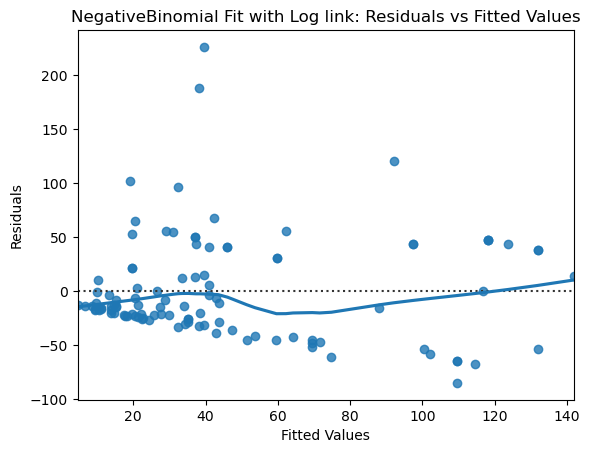

/tmp/ipykernel_2067/2306608456.py:94: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 3


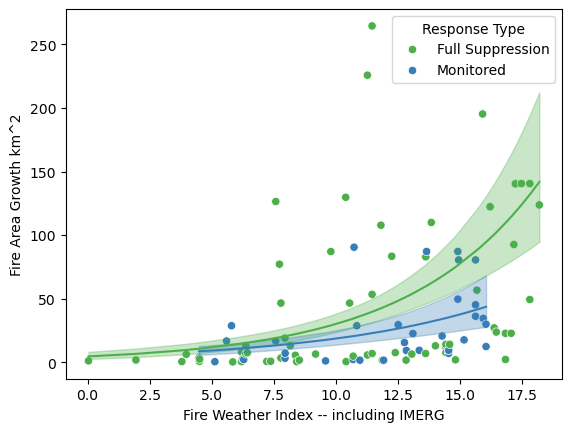

In [56]:
#& (fire3.t > "2023-06-13 12:00:00")

close_fires = ["1034", "1003", "1166", "811", "320", "315", "1089", "862", "891", "1174"]

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) & (fire3.fireID.isin(close_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)
#row_mask = (~fire3.fireID.str.contains("_")) 

df = fire3[row_mask]

df = df[['fireID', 't',  'GEOS-5.IMERGEARLY', 'FWI',
'field_response_type', 
'FWI_rolling', 'farea_diff_rolling', 'GEOS-5.IMERGEARLY_rolling',"GEOS5_IMERGEARLY_rolling", "log_farea_diff_rolling"]].dropna()

y = "farea_diff_rolling"
x = "GEOS5_IMERGEARLY_rolling"
c = "field_response_type"
#df = df.sort_values(by = x)

# Unique category labels: 'D', 'F', 'G', ...
# color_labels = df[c].unique()

# # List of RGB triplets

# #rgb_values = sns.color_palette("Set1", 3)
# #rgb_values.reverse()

# # Map label to RGB
# color_map = dict(zip(color_labels, rgb_values))

formula = f"{y} ~ {x}:C({c})"


families = ["NegativeBinomial"] ### Chosen based on BIC (and AIC)
links = ["Log"]
#links = ["Identity"]

ls = []
fs = []
aic = []
ll = []
bic = []
for f in families:
    for l in links: 
        #desc = ModelDesc.from_formula(formula)
        #desc.describe()

        #sm.families.family.Gamma.links
        #link_g = sm.genmod.families.links.Identity()
        #link_g = sm.genmod.families.links.Log()
        #link_g = sm.genmod.families.links.CLogLog()
        #link_g = sm.genmod.families.links.Sqrt()
        #link_g = sm.genmod.families.links.InversePower()
        #link_g = sm.genmod.families.links.NegativeBinomial()
        #link_g = sm.genmod.families.links.Power()
        
        link_g = getattr(sm.genmod.families.links, l)

        method = getattr(sm.families, f)

        model = smf.glm(formula, data=df, family=method(link = link_g(), check_link=True)).fit() # family=sm.families.Poisson()
        print(model.summary())
        tmp = model.summary2()
        
        fs.append(f)
        ls.append(l)
        aic.append(model.aic)
        ll.append(tmp.tables[0].iloc[2,3])
        bic.append(model.bic)



        df['fitted'] = model.fittedvalues
        df['residuals'] = model.resid_response
        df = df.sort_values(by = x)
        
        # Plot residuals vs fitted values
        res = sns.residplot(x='fitted', y='residuals', data=df, lowess=True)
        res
        plt.title(f'{f} Fit with {l} link: Residuals vs Fitted Values')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        plt.show()
        

        predictions = model.get_prediction(df, transform = True) #df, transform = False
        df['predicted'] = predictions.predicted_mean
        df['conf_int_low'], df['conf_int_high'] = predictions.conf_int().T

        actual = sns.scatterplot(x=x, y=y, data=df, hue = c, palette= color_map) # hue = c)
        actual
        handles, labels = actual.get_legend_handles_labels()

        # Customize legend titles and labels
        actual.legend(handles=handles, labels=[ "Full Suppression", "Monitored", "Modified Suppression"], title=pretty_names[c])
        # Plot the fitted values
        pred = sns.lineplot(x=x, y='predicted', data=df, hue = c, palette= color_map, legend = False) #  hue =c,
        pred
        # Plot the confidence intervals
        for cat in df[c].unique():
            #print(cat)
            #print(df.loc[(df[c] == cat), [c]].map(color_map))
            plt.fill_between(df.loc[(df[c] == cat)][x], df.loc[(df[c] == cat)]['conf_int_low'], df.loc[(df[c] == cat)]['conf_int_high'],  color=color_map[cat], alpha=0.3)

        #plt.title(f'{f} Fit with {l} link')
        plt.title('')
        plt.xlabel("Fire Weather Index -- including IMERG")
        plt.ylabel("Fire Area Growth km^2")
        #plt.legend()
        #plt.savefig(f'{os.path.abspath("some_figs/")}/Pretty_model_fit_{f}_with_{l}_{y}_func_of_{x}_via_{c}_bic{model.bic}.png', dpi = 900, transparent = False)
        plt.show()
        
stats_single_model_fwi_rolling = pd.DataFrame({"Family": fs, "Link_Function" : ls,  "Log_Likelyhood": ll, "AIC": aic, "BIC": bic})

# Misc exploratory stuff

In [ ]:
## For plot of farea_diff_folling vs GEOS-5.IMERGEEARLY_rolling, two outliers

## Outlier 10972 @ 7/07 -- Still looks like a peak temporal missmatch. Rolling over more numers didn't get rid ove it though. 

### Ourlier 10406 @ 06/22 -- looks like either som small temporal mismatch OR more likely that the IMERGE EARLY FWI got it a little better. 

fire3

In [ ]:
# import geoviews
# import hvplot.pandas
# #from bokeh.models import DatetimeTickFormatter, HoverTool







# fire3[row_mask].hvplot.scatter(x = "GEOS-5.IMERGEARLY_rolling", y = "farea_diff_rolling", hover_cols = ["fireID", "t"] )

    

In [ ]:
#fire3[(fire3.fireID.str.contains("8474")) & (fire3.t == "2023-06-07 12:00:00") ].sort_values(by = "t").fireID.unique()#.explore(style_kwds = {"fillOpacity": 0})


fire3[(fire3.fireID.str.contains("8635"))].sort_values(by = "t").fireID.unique()#.explore(style_kwds = {"fillOpacity": 0})

In [ ]:
fire3[row_mask & (fire3.fireID == "10972") ].sort_values(by = "t") ### Missing some polygons??????????
#print(fire3[row_mask & (fire3.fireID == "10972") & (~fire3.geometry.isna())].t.min())

In [ ]:



density_tansform = fire3[row_mask].groupby(["fireID", "field_response_type"]).farea.max().reset_index()
print(len(density_tansform.fireID.unique()))
print(len(density_tansform.fireID))
#density_tansform

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)

p = (ggplot(density_tansform, aes(x = "farea", color = "field_response_type"))
        #p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "farea_shifted"))
     + plotnine.geom_density()
     #+ plotnine.labels.ylab(y)
     + plotnine.labels.xlab("Maximum fire area (km^2) before merging")
     #+ stat_smooth(method = "glm")
     #+ plotnine.scale_y_log10()
     + plotnine.scale_x_log10()
     #+ plotnine.ggtitle(f"{agg_function} in rolling window of {rolling_num} days")

     )
print(p)

In [ ]:
import seaborn as sns

sns.histplot(data=density_tansform, x="farea", hue = "field_response_type")

In [ ]:
p = (ggplot(density_tansform, aes(x = "farea", fill = "field_response_type"))
        #p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "farea_shifted"))
     + plotnine.geom_histogram(bins = 17)
     #+ plotnine.labels.ylab(y)
     + plotnine.labels.xlab("Maximum fire area (km) before merging")
     #+ stat_smooth(method = "glm")
     #+ plotnine.scale_y_log10()
     + plotnine.scale_x_log10()
     #+ plotnine.ggtitle(f"{agg_function} in rolling window of {rolling_num} days")

     )
print(p)

In [ ]:
density_tansform = fire3[row_mask].groupby(["fireID", "field_response_type"]).farea.min().reset_index()
print(len(density_tansform.fireID.unique()))
print(len(density_tansform.fireID))


p = (ggplot(density_tansform, aes(x = "farea", fill = "field_response_type"))
        #p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "farea_shifted"))
     + plotnine.geom_histogram(bins = 17)
     #+ plotnine.labels.ylab(y)
     + plotnine.labels.xlab("Fire area (km^2) at start of fire")
     #+ stat_smooth(method = "glm")
     #+ plotnine.scale_y_log10()
     + plotnine.scale_x_log10()
     #+ plotnine.ggtitle(f"{agg_function} in rolling window of {rolling_num} days")

     )
print(p)

In [ ]:

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)


p = (ggplot(fire3[row_mask], aes(x = "farea_diff", color = "field_response_type"))
        #p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "farea_shifted"))
     #+ plotnine.geom_histogram(bins = 17)
     + plotnine.geom_density()
     #+ plotnine.labels.ylab(y)
     + plotnine.labels.xlab("difference in fire area (km^2)")
     #+ stat_smooth(method = "glm")
     #+ plotnine.scale_y_log10()
     + plotnine.scale_x_log10()
     #+ plotnine.ggtitle(f"{agg_function} in rolling window of {rolling_num} days")

     )
print(p)

In [ ]:
density_tansform[density_tansform.farea >= 500]

In [ ]:
# #from plotnine import *

# df = pd.DataFrame({
#     'x': [1, 2, 3, 4, 5],
#     'y': [1, 4, 9, 16, 25],
#     'color_var': [1, 1, 2, 2, 3]  # Numerical variable
# })

# # Plot using ggplot (plotnine) with numerical gradient color scale
# p = (ggplot(df, aes(x='x', y='y', color='color_var')) +
#      geom_point() +
#      scale_color_continuous(low="#0000FF", high="#FF0000") +  # Specify the colors for low and high values
#      labs(title='Plot with Numerical Gradient Color Scale')
#     )

# print(p)

In [ ]:
fire3.columns

In [ ]:
# fire3[['fireID', 't', 'farea_diff', 'FWI_diff', 'FWI_rolling',
#        'day_of_fire', 'farea_shifted', 'normalized_farea_diff',
#        'FWI_diff_rolling', 'farea_rolling', 'farea_diff_rolling',
#        'max_dof', 'duration']]

In [ ]:
 p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "field_response_type"))
         + geom_point()
         + plotnine.labels.ylab(y)
         + plotnine.labels.xlab(x)
         + stat_smooth(method = "glm")
         #+ plotnine.scale_y_log10()
         + plotnine.ggtitle(f"{agg_function} in window of {rolling_num}")

        )
print(p)

In [ ]:
FWI_sorted = fire3[row_mask].sort_values(by = "FWI", ascending= True)

In [ ]:
FWI_sorted[(FWI_sorted.farea_diff >= 50) & FWI_sorted.FWI <= 3].t.astype("datetime64[ns]").hist()

In [ ]:
#FWI_sorted[(FWI_sorted.farea_diff >= 50) & FWI_sorted.FWI <= 3].lat.hist()

In [ ]:
FWI_sorted.columns

# FWI_sorted = FWI_sorted[['fireID', 't', 'geometry',
#        'n_pixels', 'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration',
#        'pixden', 'meanFRP', 'GEOS-5.IMERGEARLY', 'FWI', 'FWI_lead_1',
#        'FWI_lead_2', 'FWI_lead_3', 'FWI_lead_4', 'FWI_lead_5', 'FWI_lead_6',
#        'FWI_lead_7', 'FWI_lead_8', 'farea_diff']]

In [ ]:
big_sp_low_fwi = FWI_sorted[(FWI_sorted.farea_diff >= 50) & FWI_sorted.FWI <= 3]

big_sp_big_fwi = FWI_sorted[(FWI_sorted.farea_diff >= 100) & (FWI_sorted.FWI >= 10)]

low_sp_big_fwi = FWI_sorted[(FWI_sorted.farea_diff <= 100) & (FWI_sorted.FWI >= 10)]

In [ ]:
big_sp_low_fwi = big_sp_low_fwi.to_crs("EPSG:4326")
big_sp_big_fwi = big_sp_big_fwi.to_crs("EPSG:4326")

In [ ]:
big_sp_low_fwi.to_file("/projects/old_shared/fire_weather_vis/Lightning_analysis/Shapefiles/big_spread_low_fwi/low_FWI.shp")

In [ ]:
big_sp_big_fwi.to_file("/projects/old_shared/fire_weather_vis/Lightning_analysis/Shapefiles/big_spread_high_fwi/high_FWI.shp")

In [ ]:
import matplotlib.pyplot as plt

big_sp_big_fwi.t.astype("datetime64[ns]").hist()
plt.xticks(rotation='vertical')

In [ ]:
big_sp_low_fwi.t.astype("datetime64[ns]").hist()

In [ ]:
big_sp_big_fwi

In [ ]:
big_sp_big_fwi

In [ ]:
#import skgstat as skg

In [ ]:
big_sp_big_fwi

In [ ]:
low_sp_big_fwi.columns

In [ ]:
low_sp_big_fwi[['fireID', 't', 'geometry', 'n_pixels', 'n_newpixels', 'farea', 'fperim',
       'flinelen', 'duration', 'meanFRP', 'GEOS-5.IMERGEARLY', 'FWI', 'farea_diff']]

In [ ]:
plt.scatter(low_sp_big_fwi.farea_diff.astype("float"), low_sp_big_fwi["GEOS-5.IMERGEARLY"].astype("float"))
plt.show()

In [ ]:
plt.scatter(low_sp_big_fwi.farea_diff.astype("float"), low_sp_big_fwi["FWI"].astype("float"))
plt.show()

In [ ]:
### Playing with growth rate

fire3["flinelen_shifted"] = fire3.groupby("fireID").flinelen.shift(periods = 1)
fire3["fperim_shifted"] = fire3.groupby("fireID").fperim.shift(periods = 1)
fire3["flinelen_diff"] = fire3.groupby("fireID").flinelen.diff()
fire3["fperim_diff"] = fire3.groupby("fireID").fperim.diff()


### Implementing FBP technical handbook equation 88 https://drive.google.com/file/d/1xBseasON22KFC4jEVBKk75EOuUK-dpM2/view

#1) Calculate the length and breadth of the fires. Simple way, get just the convex hull and the longer one is length. More complex, length shoudl maybe be tied to where active fire line is (to represent head fire?)
from shapely.geometry import LineString

def get_length_to_breadth(polygon):
    
    mbr_points = list(zip(*polygon.minimum_rotated_rectangle.exterior.coords.xy)) ### oh no projection issues? 
    # calculate the length of each side of the minimum bounding rectangle
    mbr_lengths = [LineString((mbr_points[i], mbr_points[i+1])).length for i in range(len(mbr_points) - 1)]

    # get major/minor axis measurements
    minor_axis = min(mbr_lengths)
    major_axis = max(mbr_lengths)
    
    return(major_axis/minor_axis)



fire3["LB"] = fire3.geometry.apply(get_length_to_breadth)


## Calculate spread rate

row_mask = (fire3.fperim_diff > 0.1) & (fire3.flinelen > 0)
perimeter_growth_rate = fire3[row_mask]["fperim_diff"] ### Modify by length of active fire line? 
LB = fire3[row_mask]["LB"]


fire3["spread_rate"] = np.nan
fire3.loc[row_mask, "spread_rate"] = 1/(2*((np.pi * (1+(1/LB)) * (1 + ((LB -1)/(2*(LB+1)))**2)) / perimeter_growth_rate ))


fire3["flinelen_rolling"]  = fire3.groupby("fireID").flinelen.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3["flinelen_diff_rolling"] = fire3.groupby("fireID").flinelen_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3["fperim_rolling"] = fire3.groupby("fireID").fperim.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3["fperim_diff_rolling"] = fire3.groupby("fireID").fperim_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
fire3["spread_rate_rolling"] = fire3.groupby("fireID").spread_rate.rolling(rolling_num).agg(agg_function).reset_index(drop = True)


long_fires = fire3[fire3.day_of_fire > 3].fireID.unique()
#fire3['max_dof'] = fire3.groupby("fireID").day_of_fire.max()

row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)

#x_var = ["FWI","FWI_rolling", "FWI_diff_rolling", "FWI_norm_rolling"]
#y_var = ['farea', "normalized_farea_diff", 'farea_rolling', 'farea_diff_rolling']

#x_var = ["FWI","FWI_rolling", "FWI_diff_rolling"]
#y_var = ["flinelen", "flinelen_rolling", "flinelen_diff_rolling", "fperim_rolling", "fperim_diff_rolling", "spread_rate", "spread_rate_rolling"]

x_var = ["FWI","FWI_rolling", "FWI_diff_rolling", "GEOS-5.IMERGEARLY", "GEOS-5.IMERGEARLY_rolling"]
y_var = ["flinelen_shifted", "spread_rate", "spread_rate_rolling"]


for x in x_var:
    for y in y_var:
        #p = (ggplot(fire3[row_mask], aes( x = x, y = y))
        p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "field_response_type"))
        #p = (ggplot(fire3[row_mask], aes( x = x, y = y, color = "farea_shifted"))
         + geom_point()
         + plotnine.labels.ylab(y)
         + plotnine.labels.xlab(x)
         + stat_smooth(method = "glm")
         #+ plotnine.scale_y_log10()
         + plotnine.ggtitle(f"{agg_function} in rolling window of {rolling_num} days")

         )
        print(p)
        #del(p)

In [ ]:
row_mask = fire3.farea_diff >0.1

# plt.scatter(fire3[row_mask].farea_diff, ((fire3[row_mask].flinelen_shifted) * fire3[row_mask]["GEOS-5.IMERGEARLY"]))
# plt.show()

y = "farea_diff"



p = (ggplot(fire3[row_mask], aes(x = (fire3[row_mask].flinelen_shifted) * fire3[row_mask]["GEOS-5.IMERGEARLY"], y = y, color = "field_response_type"))
+ geom_point()
+ plotnine.labels.ylab(y)
+ plotnine.labels.xlab("fireline len * FWI")
+ stat_smooth(method = "glm")
+ plotnine.ggtitle(f"{agg_function} in rolling window of {rolling_num} days"))
print(p)

In [ ]:
y = "fperim_diff"


p = (ggplot(fire3[row_mask], aes(x = (fire3[row_mask].flinelen_shifted) * fire3[row_mask]["GEOS-5.IMERGEARLY"], y = y, color = "field_response_type"))
+ geom_point()
+ plotnine.labels.ylab(y)
+ plotnine.labels.xlab("fireline len * FWI")
+ stat_smooth(method = "glm")
+ plotnine.ggtitle(f"{agg_function} in rolling window of {rolling_num} days"))
print(p)

In [ ]:
fuels.to_file('fires_with_dominant_landcover_test_20240722.csv')